# Master Thesis Result Analysis — Core Evaluation Design

This notebook implements the main result analysis for the master thesis, focusing on the **three core Dependent Variables (DVs)** evaluated for each leadership style and task type:

1. **Output Quality** (LLM-as-Judge): 4 dimensions (Accuracy, Completeness, Cohesion, Quality) + data trap catch rates.
2. **Efficiency** (automatically tracked): Total tokens, wall-clock duration, and revision rounds.
3. **Worker Satisfaction** (6-item Likert survey): Composite mean per worker and team (1–5 scale).

The **4th dimension, sentiment analysis**, is evaluated separately in `03_sentiment_analysis.ipynb`.
The **5th dimension, validity and manipulation checks**, is evaluated separately in `02_validation_check.ipynb`.


## §0 — Setup & Data Loading

Import core analytical dependencies, set up publication-ready plotting aesthetics, and load the master experiment dataset across all 70 runs (7 leadership styles × 2 task complexities × 5 repetitions).


In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from pathlib import Path

# Set visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14

STYLE_COLORS = {
    'coercive': '#e41a1c',       # Red
    'authoritative': '#ff7f0e',  # Orange
    'affiliative': '#ff80c5',    # Pink
    'democratic': '#377eb8',     # Blue
    'pacesetting': '#984ea3',    # Purple
    'coaching': '#4daf4a',       # Green
    'baseline': '#7f7f7f'        # Gray
}

STYLE_ORDER = ['coercive', 'authoritative', 'affiliative', 'democratic', 'pacesetting', 'coaching', 'baseline']

WORKERS = ['Coder', 'Writer', 'Reviewer']

AGENT_COLORS = {
    'Boss': '#FF3366',
    'Coder': '#00D4FF',
    'Writer': '#0066FF',
    'Reviewer': '#7B2CBF',
    'Team Mean': '#00E5A3'
}

# Recolor bars/boxes so short = 50% transparent, long = opaque
def color_style_task_bars(ax, edgecolor='white'):
    # ax.containers groups bars/boxes by hue in hue_order ['short', 'long'].
    # Each container holds one artist per style in STYLE_ORDER.
    for j, container in enumerate(ax.containers):
        task = ['short', 'long'][j]
        alpha = 0.5 if task == 'short' else 1.0
        for i, artist in enumerate(container):
            style = STYLE_ORDER[i]
            # Boxplots use BoxPlotArtists; the colored patch is artist.box
            patch = artist.box if hasattr(artist, 'box') else artist
            patch.set_facecolor(to_rgba(STYLE_COLORS[style], alpha=alpha))
            if edgecolor:
                patch.set_edgecolor(edgecolor)


def add_short_long_legend(ax=None, fig=None, sample_color='#555555', title='Task', loc='upper right', **kwargs):
    """Add a legend that explains short = 50% transparent, long = opaque."""
    handles = [
        Patch(facecolor=to_rgba(sample_color, 0.5), edgecolor='black', label='Short task'),
        Patch(facecolor=to_rgba(sample_color, 1.0), edgecolor='black', label='Long task')
    ]
    if fig is not None:
        return fig.legend(handles=handles, title=title, loc=loc, frameon=False, **kwargs)
    return ax.legend(handles=handles, title=title, loc=loc, frameon=False, **kwargs)


# Resolve results path relative to the notebook's location
RESULTS_DIR = os.path.abspath(os.path.join('..', 'results'))

run_dirs = sorted([
    os.path.join(RESULTS_DIR, d)
    for d in os.listdir(RESULTS_DIR)
    if os.path.isdir(os.path.join(RESULTS_DIR, d)) and '_run' in d
])

print(f'Resolved RESULTS_DIR: {os.path.abspath(RESULTS_DIR)}')
print(f'Found {len(run_dirs)} total run directories in results/')

# Load all run artifacts into a single DataFrame
rows = []
for run_dir in run_dirs:
    meta_path = os.path.join(run_dir, 'metadata.json')
    eval_path = os.path.join(run_dir, 'evaluation.json')
    surv_path = os.path.join(run_dir, 'survey_results.json')

    if not all(os.path.exists(p) for p in [meta_path, eval_path, surv_path]):
        continue

    try:
        with open(meta_path, 'r', encoding='utf-8') as f:
            meta = json.load(f)
        with open(eval_path, 'r', encoding='utf-8') as f:
            eval_data = json.load(f)
        with open(surv_path, 'r', encoding='utf-8') as f:
            survey = json.load(f)
    except Exception as e:
        print(f'Skipped {os.path.basename(run_dir)}: {e}')
        continue

    folder = os.path.basename(run_dir)
    parts = folder.split('_')
    style = parts[0] if len(parts) > 0 else meta.get('leadership_style', '')
    task = parts[1] if len(parts) > 1 else meta.get('task_type', '')

    scores = eval_data.get('scores', {})
    workers = survey.get('workers', {})

    def get_score(dim):
        s = scores.get(dim)
        return s.get('score') if isinstance(s, dict) else s

    row = {
        'folder': folder,
        'style': style,
        'task': task,
        'run_id': meta.get('run_id'),
        'total_tokens': meta.get('total_tokens'),
        'total_input_tokens': meta.get('total_input_tokens'),
        'total_output_tokens': meta.get('total_output_tokens'),
        'total_api_calls': meta.get('total_api_calls'),
        'total_code_executions': meta.get('total_code_executions'),
        'total_messages': meta.get('total_messages'),
        'duration_seconds': meta.get('duration_seconds'),
        'revision_rounds': meta.get('revision_rounds'),
        'quality_mean': eval_data.get('quality_mean'),
        'overall_quality': eval_data.get('overall_quality'),
        'trap_catch_rate': eval_data.get('trap_catch_rate'),
        'accuracy': get_score('accuracy'),
        'completeness': get_score('completeness'),
        'cohesion': get_score('cohesion'),
        'quality': get_score('quality'),
        'survey_team_mean': survey.get('team_mean'),
        'survey_coder': workers.get('Coder', {}).get('composite_score') if isinstance(workers.get('Coder'), dict) else None,
        'survey_writer': workers.get('Writer', {}).get('composite_score') if isinstance(workers.get('Writer'), dict) else None,
        'survey_reviewer': workers.get('Reviewer', {}).get('composite_score') if isinstance(workers.get('Reviewer'), dict) else None,
    }

    # Per-trap status as numeric scores (caught=1, partial=0.5, missed=0)
    status_scores = {'caught': 1.0, 'partial': 0.5, 'missed': 0.0}
    for trap_id, info in eval_data.get('traps', {}).items():
        row[f'trap_{trap_id}'] = status_scores.get(info.get('status'), 0.0)

    rows.append(row)

df = pd.DataFrame(rows)
if not df.empty:
    df['style'] = pd.Categorical(df['style'], categories=STYLE_ORDER, ordered=True)

trap_cols = [c for c in df.columns if c.startswith('trap_')]
df[trap_cols] = df[trap_cols].fillna(0.0)

print(f'\nLoaded {len(df)} runs into df with columns: {list(df.columns)}')

# ── Figure export ────────────────────────────────────────────────────────────
# Figures produced below are written to the local `figures/` folder as PNG files.

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)


def save_fig(name, dpi=200):
    """Write the current matplotlib figure to `figures/<name>.png`."""
    plt.gcf().savefig(FIG_DIR / f'{name}.png', dpi=dpi, bbox_inches='tight', facecolor='white')


Resolved RESULTS_DIR: /Users/hellligkeit/Documents/FS/Masterthesis/MAS/results
Found 70 total run directories in results/

Loaded 70 runs into df with columns: ['folder', 'style', 'task', 'run_id', 'total_tokens', 'total_input_tokens', 'total_output_tokens', 'total_api_calls', 'total_code_executions', 'total_messages', 'duration_seconds', 'revision_rounds', 'quality_mean', 'overall_quality', 'trap_catch_rate', 'accuracy', 'completeness', 'cohesion', 'quality', 'survey_team_mean', 'survey_coder', 'survey_writer', 'survey_reviewer', 'trap_sentinel_values', 'trap_outlier_79c', 'trap_trivial_features', 'trap_duplicate_unit_features', 'trap_country_name_duplicates', 'trap_city_name_duplicates']


In [2]:
# Build the same run-level metadata frame used in 02_validation_check
meta_records = []

for d in run_dirs:
    meta_file = os.path.join(d, 'metadata.json')
    if os.path.exists(meta_file):
        with open(meta_file, 'r', encoding='utf-8') as f:
            try:
                meta = json.load(f)
            except json.JSONDecodeError:
                continue
        meta_records.append({
            'run': os.path.basename(d),
            'style': os.path.basename(d).split('_')[0],
            'task': os.path.basename(d).split('_')[1],
            'revision_rounds': meta.get('revision_rounds', 0),
            'max_revision_rounds': meta.get('max_revision_rounds', 2)
        })

df_meta = pd.DataFrame(meta_records)


#### Descriptive Overview by Style and Task

Quick numeric summary of the main dependent variables by leadership style and task. The table reports group means for output quality, efficiency, and worker satisfaction; it provides an orientation before the detailed analyses and is not a statistical test in itself.

In [3]:
main_summary = (df.groupby(['style', 'task'])
                   .agg(quality_mean=('quality_mean', 'mean'),
                        trap_catch_rate=('trap_catch_rate', 'mean'),
                        total_tokens=('total_tokens', 'mean'),
                        total_input_tokens=('total_input_tokens', 'mean'),
                        total_output_tokens=('total_output_tokens', 'mean'),
                        total_api_calls=('total_api_calls', 'mean'),
                        total_code_executions=('total_code_executions', 'mean'),
                        duration_seconds=('duration_seconds', 'mean'),
                        revision_rounds=('revision_rounds', 'mean'),
                        survey_team_mean=('survey_team_mean', 'mean'))
                   .reset_index()
                   .sort_values(['style', 'task']))
print('Summary of the three main result dimensions by style and task:')
print(main_summary.round(2).to_string(index=False))

Summary of the three main result dimensions by style and task:
        style  task  quality_mean  trap_catch_rate  total_tokens  total_input_tokens  total_output_tokens  total_api_calls  total_code_executions  duration_seconds  revision_rounds  survey_team_mean
     coercive  long          3.90             0.52      187680.2            164517.8              23162.4             19.4                    2.6            254.31              0.4              4.59
     coercive short          2.55             0.13      131833.2            118571.2              13262.0             20.0                    2.0            152.72              1.0              4.16
authoritative  long          4.30             0.55      217174.8            191573.4              25601.4             19.4                    2.6            299.29              0.6              4.91
authoritative short          2.65             0.00      153633.0            138777.0              14856.0             19.4                   

In [4]:
# Export the run-level dataframe to the notebooks directory using openpyxl
xlsx_path = os.path.abspath('MAS_results.xlsx')
df.to_excel(xlsx_path, index=False, engine='openpyxl')
print(f'Exported {len(df)} runs to {xlsx_path}')
print('Columns:', list(df.columns))

Exported 70 runs to /Users/hellligkeit/Documents/FS/Masterthesis/MAS/notebooks/MAS_results.xlsx
Columns: ['folder', 'style', 'task', 'run_id', 'total_tokens', 'total_input_tokens', 'total_output_tokens', 'total_api_calls', 'total_code_executions', 'total_messages', 'duration_seconds', 'revision_rounds', 'quality_mean', 'overall_quality', 'trap_catch_rate', 'accuracy', 'completeness', 'cohesion', 'quality', 'survey_team_mean', 'survey_coder', 'survey_writer', 'survey_reviewer', 'trap_sentinel_values', 'trap_outlier_79c', 'trap_trivial_features', 'trap_duplicate_unit_features', 'trap_country_name_duplicates', 'trap_city_name_duplicates']


## §1 — Output Quality (LLM-as-Judge + Data Traps)

Evaluate task deliverable performance scored by the Control Agent across the 4 core dimensions (1–5 scale) and data quality trap catch rates compared against ground truth.


### §1.1 — Overall Quality Score by Leadership Style

Barplot of mean overall output quality by leadership style and task (short vs. long), with standard-error bars. We can see whether any leadership style consistently produces higher- or lower-quality deliverables and whether the effect differs by task type.

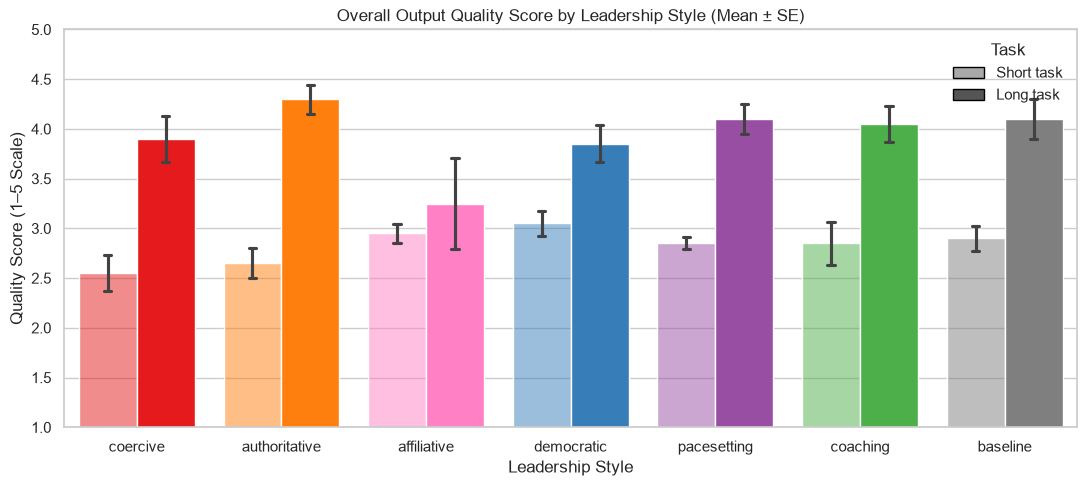

            style   task  mean       std
0        coercive   long  3.90  0.518411
1        coercive  short  2.55  0.410792
2   authoritative   long  4.30  0.325960
3   authoritative  short  2.65  0.335410
4     affiliative   long  3.25  1.030776
5     affiliative  short  2.95  0.209165
6      democratic   long  3.85  0.418330
7      democratic  short  3.05  0.273861
8     pacesetting   long  4.10  0.335410
9     pacesetting  short  2.85  0.136931
10       coaching   long  4.05  0.410792
11       coaching  short  2.85  0.487340
12       baseline   long  4.10  0.454148
13       baseline  short  2.90  0.285044


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=df, x='style', y='quality_mean', hue='task', order=STYLE_ORDER, errorbar='se', capsize=0.1, ax=ax, legend=False, hue_order=['short', 'long'])
color_style_task_bars(ax)
add_short_long_legend(ax)

ax.set_title('Overall Output Quality Score by Leadership Style (Mean ± SE)')
ax.set_ylabel('Quality Score (1–5 Scale)')
ax.set_xlabel('Leadership Style')
ax.set_ylim(1, 5)
plt.tight_layout()
save_fig('03_quality_by_style')
plt.show()

# Print summary table
quality_summary = df.groupby(['style', 'task'])['quality_mean'].agg(['mean', 'std']).reset_index()
print(quality_summary)

### §1.2 — Quality Dimension Breakdown (Accuracy, Completeness, Cohesion, Quality)

Heatmap of mean scores across the four LLM-judge quality dimensions and all seven leadership styles. This shows whether a style is uniformly strong or weak, or whether its effects are concentrated in specific quality dimensions.

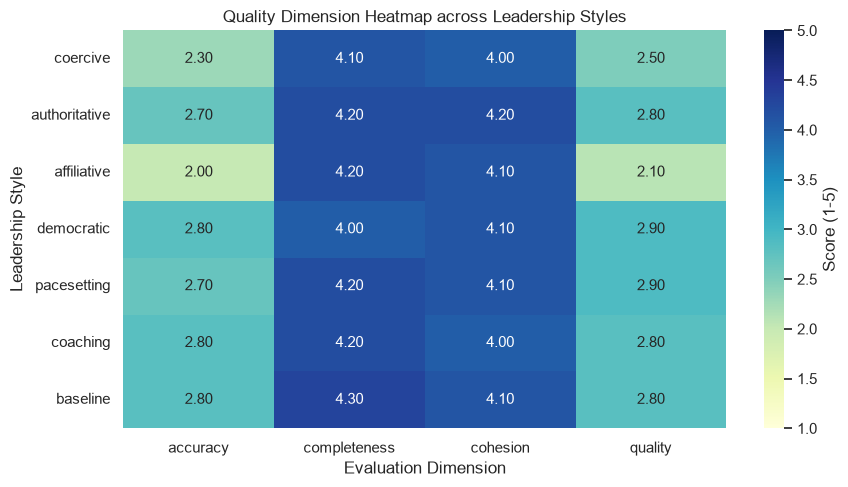

In [6]:
dim_cols = ['accuracy', 'completeness', 'cohesion', 'quality']
dim_means = df.groupby('style')[dim_cols].mean().reindex(STYLE_ORDER)

plt.figure(figsize=(9, 5))
sns.heatmap(dim_means, annot=True, cmap='YlGnBu', fmt='.2f', vmin=1, vmax=5, cbar_kws={'label': 'Score (1-5)'})
plt.title('Quality Dimension Heatmap across Leadership Styles')
plt.xlabel('Evaluation Dimension')
plt.ylabel('Leadership Style')
plt.tight_layout()
save_fig('03_quality_dimension_heatmap')
plt.show()

### §1.3 — Data Trap Detection Performance

Barplot of mean trap-catch rate by leadership style and task, with standard-error bars. It reveals whether any style is systematically better at catching the planted data-quality traps.

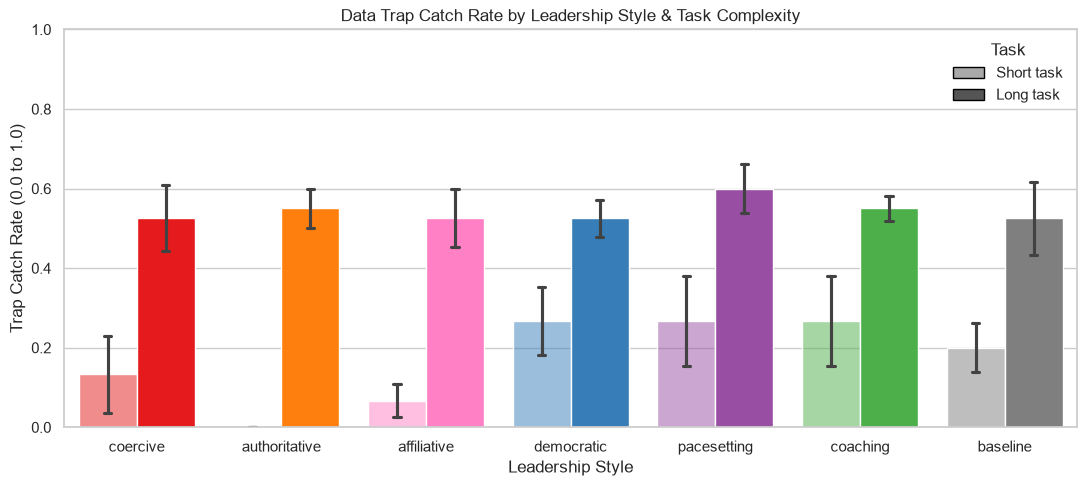

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=df, x='style', y='trap_catch_rate', hue='task', order=STYLE_ORDER, errorbar='se', capsize=0.1, ax=ax, legend=False, hue_order=['short', 'long'])
color_style_task_bars(ax)
add_short_long_legend(ax)

ax.set_title('Data Trap Catch Rate by Leadership Style & Task Complexity')
ax.set_ylabel('Trap Catch Rate (0.0 to 1.0)')
ax.set_xlabel('Leadership Style')
ax.set_ylim(0, 1.0)
plt.tight_layout()
save_fig('03_trap_catch_rate_by_style')
plt.show()

### §1.4 — Quality by Task and Dimension (Deep Dive)

The control agent evaluates four quality dimensions independently. Because leadership style may have different effects on Accuracy, Completeness, Cohesion, and Quality, we split the analysis by task type (short vs. long). Long and short tasks differ in complexity: short tasks require four charts and a 100-word summary, while long tasks require predictive modeling and a 400-word report. Different styles may therefore develop in different dimensions.

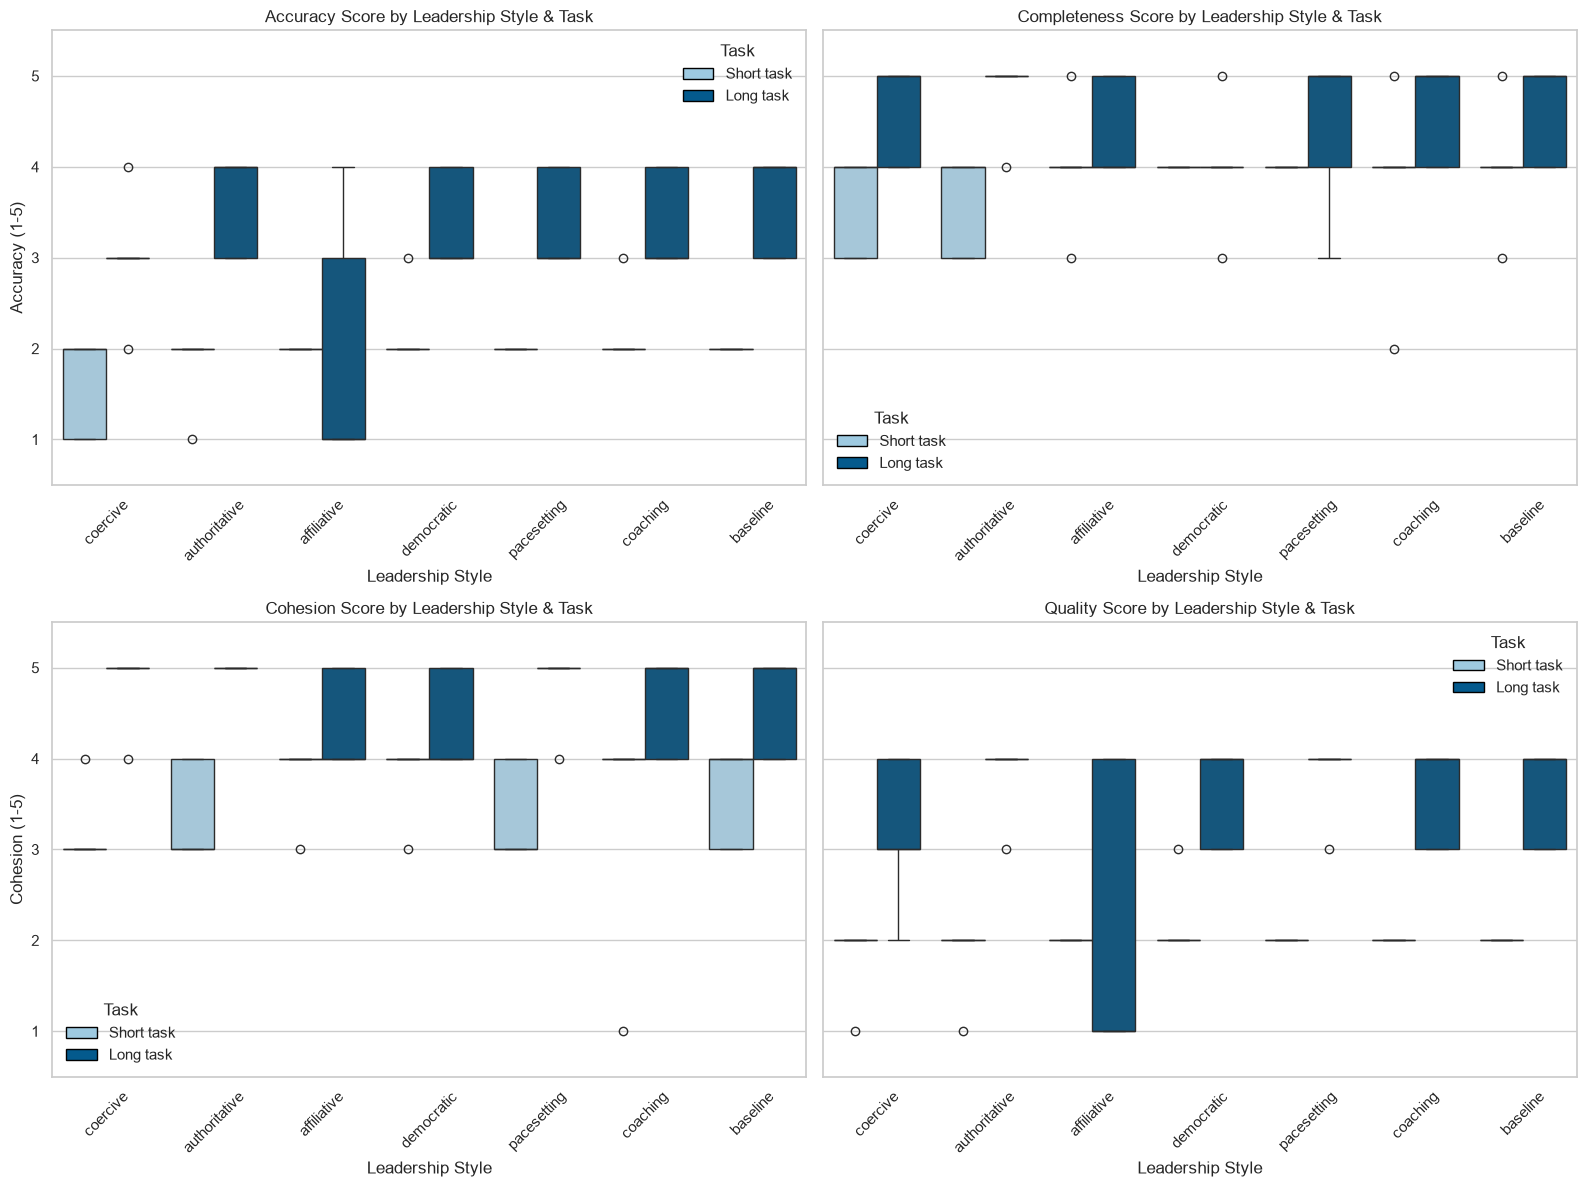

Mean quality dimension scores by task and style:
 task         style  accuracy  completeness  cohesion  quality
 long      coercive       3.0           4.6       4.8      3.2
 long authoritative       3.6           4.8       5.0      3.8
 long   affiliative       2.0           4.4       4.4      2.2
 long    democratic       3.4           4.0       4.4      3.6
 long   pacesetting       3.4           4.4       4.8      3.8
 long      coaching       3.4           4.6       4.6      3.6
 long      baseline       3.6           4.6       4.6      3.6
short      coercive       1.6           3.6       3.2      1.8
short authoritative       1.8           3.6       3.4      1.8
short   affiliative       2.0           4.0       3.8      2.0
short    democratic       2.2           4.0       3.8      2.2
short   pacesetting       2.0           4.0       3.4      2.0
short      coaching       2.2           3.8       3.4      2.0
short      baseline       2.0           4.0       3.6      2.0


In [8]:
dim_cols = ['accuracy', 'completeness', 'cohesion', 'quality']

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()
legend_locs = ['upper right', 'lower left', 'lower left', 'upper right']
for i, dim in enumerate(dim_cols):
    ax = axes[i]
    TASK_COLORS = {'short': '#9ecae1', 'long': '#045a8d'}
    sns.boxplot(data=df, x='style', y=dim, hue='task', order=STYLE_ORDER, ax=ax, legend=False, hue_order=['short', 'long'], palette=TASK_COLORS)
    handles = [
        Patch(facecolor=TASK_COLORS['short'], edgecolor='black', label='Short task'),
        Patch(facecolor=TASK_COLORS['long'], edgecolor='black', label='Long task')
    ]
    ax.legend(handles=handles, title='Task', loc=legend_locs[i], frameon=False)

    ax.set_title(f'{dim.title()} Score by Leadership Style & Task')
    ax.set_ylabel(f'{dim.title()} (1-5)')
    ax.set_xlabel('Leadership Style')
    ax.set_ylim(0.5, 5.5)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_fig('03_quality_dimensions_by_task')
plt.show()

# Summary table
dim_summary = df.groupby(['task', 'style'])[dim_cols].mean().reset_index().sort_values(['task', 'style'])
print('Mean quality dimension scores by task and style:')
print(dim_summary.round(2).to_string(index=False))

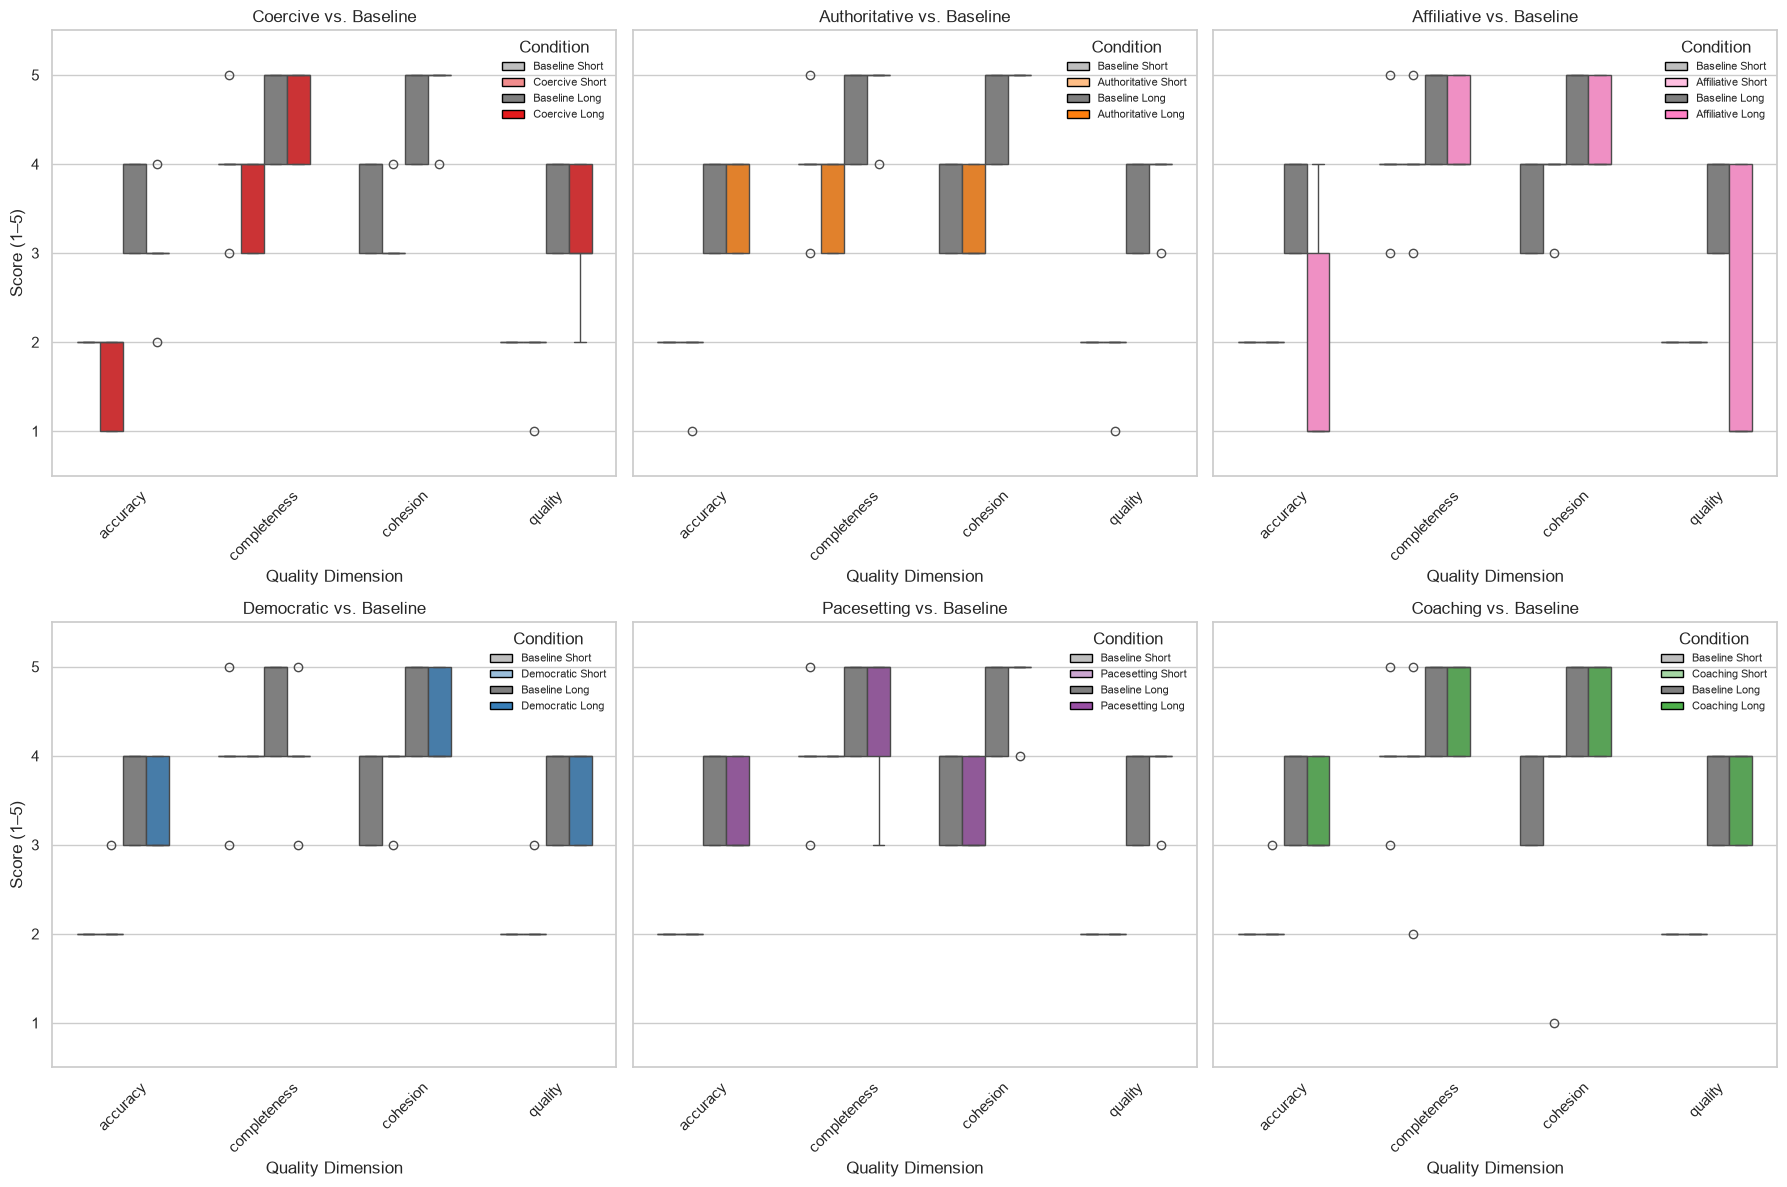

In [9]:
dim_cols = ['accuracy', 'completeness', 'cohesion', 'quality']

# Long-format data for the four quality dimensions
df_melt = df[['style', 'task'] + dim_cols].melt(
    id_vars=['style', 'task'],
    value_vars=dim_cols,
    var_name='dimension',
    value_name='score'
)

# Exclude baseline; one panel per non-baseline leadership style
non_baseline_styles = [s for s in STYLE_ORDER if s != 'baseline']

fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharey=True)
axes = axes.flatten()

for i, style in enumerate(non_baseline_styles):
    ax = axes[i]
    subset = df_melt[df_melt['style'].isin(['baseline', style])].copy()
    subset['condition'] = subset['style'].astype(str) + ' ' + subset['task'].astype(str)

    condition_order = [
        'baseline short',
        f'{style} short',
        'baseline long',
        f'{style} long'
    ]

    palette = {
        'baseline short': to_rgba('#7f7f7f', 0.5),
        f'{style} short': to_rgba(STYLE_COLORS[style], 0.5),
        'baseline long': '#7f7f7f',
        f'{style} long': STYLE_COLORS[style]
    }

    sns.boxplot(
        data=subset,
        x='dimension',
        y='score',
        hue='condition',
        order=dim_cols,
        hue_order=condition_order,
        palette=palette,
        width=0.65,
        dodge=True,
        ax=ax,
        legend=False
    )

    # Per-panel legend with the actual baseline and style colors
    condition_labels = {c: ' '.join(w.title() for w in c.split()) for c in condition_order}
    handles = [Patch(facecolor=palette[c], edgecolor='black', label=condition_labels[c]) for c in condition_order]
    ax.legend(handles=handles, title='Condition', loc='upper right', frameon=False, fontsize=8)

    ax.set_title(f'{style.title()} vs. Baseline')
    ax.set_ylabel('Score (1–5)')
    ax.set_xlabel('Quality Dimension')
    ax.set_ylim(0.5, 5.5)
    ax.tick_params(axis='x', rotation=45)

# Legends are now added inside each panel

plt.tight_layout()
save_fig('03_quality_dimensions_by_style')
plt.show()


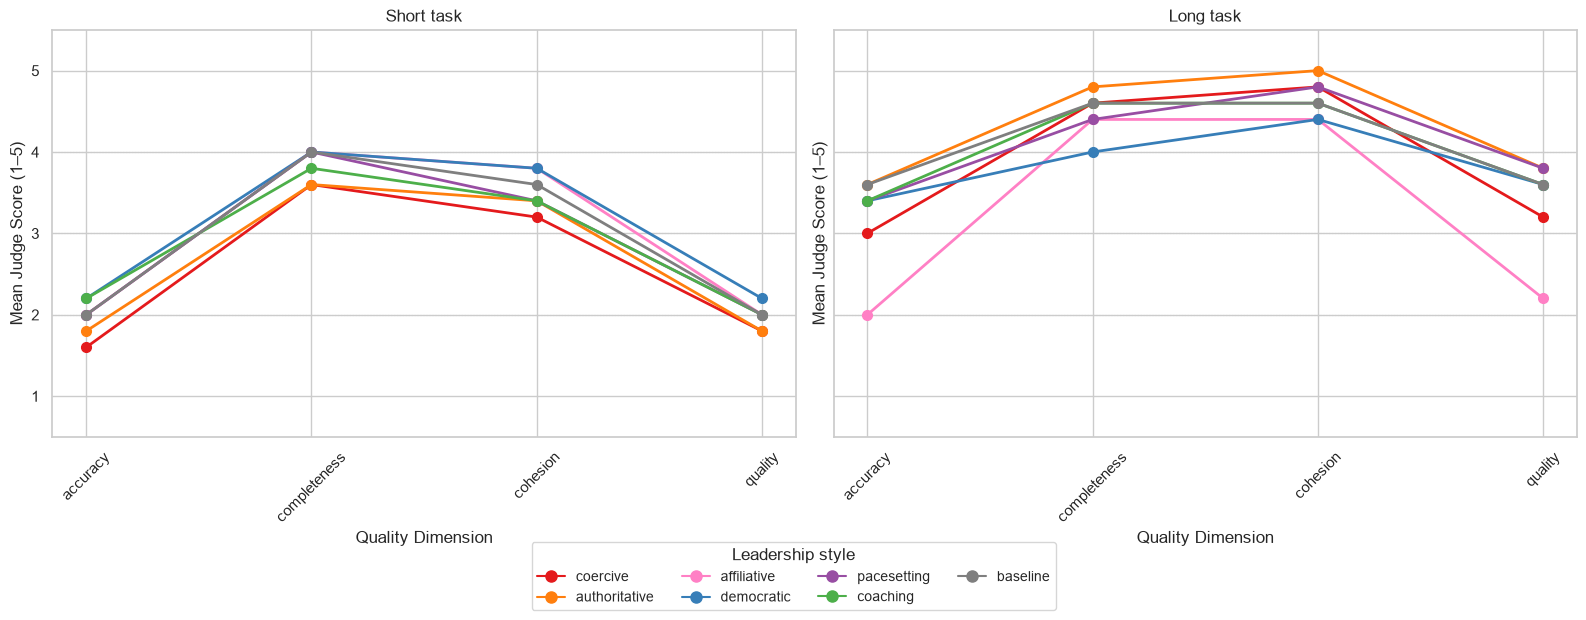

In [10]:
dim_cols = ['accuracy', 'completeness', 'cohesion', 'quality']

# Long-format quality dimensions for the line chart
df_dim = (df[['style', 'task'] + dim_cols]
          .melt(id_vars=['style', 'task'],
                value_vars=dim_cols,
                var_name='dimension',
                value_name='score'))

# Mean judge score per style, task and dimension
df_dim_mean = (df_dim
               .groupby(['style', 'task', 'dimension'], observed=True)['score']
               .mean()
               .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

style_handles = []
for style in STYLE_ORDER:
    color = STYLE_COLORS[style]
    style_handles.append(Line2D([0], [0], color=color, marker='o', markersize=8, label=style))
    for ax, task in zip(axes, ['short', 'long']):
        task_data = df_dim_mean[
            (df_dim_mean['style'].astype(str) == style) & (df_dim_mean['task'].astype(str) == task)
        ].set_index('dimension').reindex(dim_cols)
        ax.plot(
            dim_cols,
            task_data['score'],
            color=color,
            marker='o',
            markersize=7,
            linewidth=2,
            label=style
        )

for ax, task in zip(axes, ['short', 'long']):
    ax.set_title(f'{task.title()} task')
    ax.set_ylim(0.5, 5.5)
    ax.set_ylabel('Mean Judge Score (1–5)')
    ax.set_xlabel('Quality Dimension')
    ax.tick_params(axis='x', rotation=45)
    for y in [2, 3, 4]:
        ax.axhline(y, color='lightgray', linestyle=':', linewidth=0.8, zorder=0)

# One shared style legend below the two subplots
fig.legend(handles=style_handles, title='Leadership style', loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.04), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
save_fig('03_quality_dimension_lines')
plt.show()


### §1.5 — Trap Catch Rates

Data quality traps are task-specific. For the short task, the traps are the 79.3°C outlier, country name duplicates, and city name duplicates. For the long task, the traps are trivial features, sentinel values, the 79.3°C outlier, and duplicate unit features. This section shows which styles are most effective at catching each trap, using the control agent's judgment.

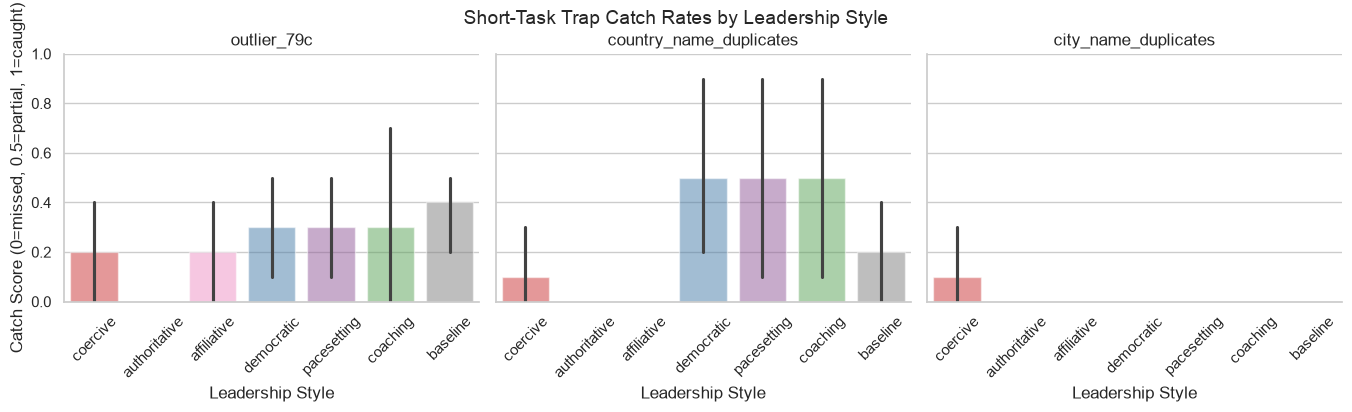

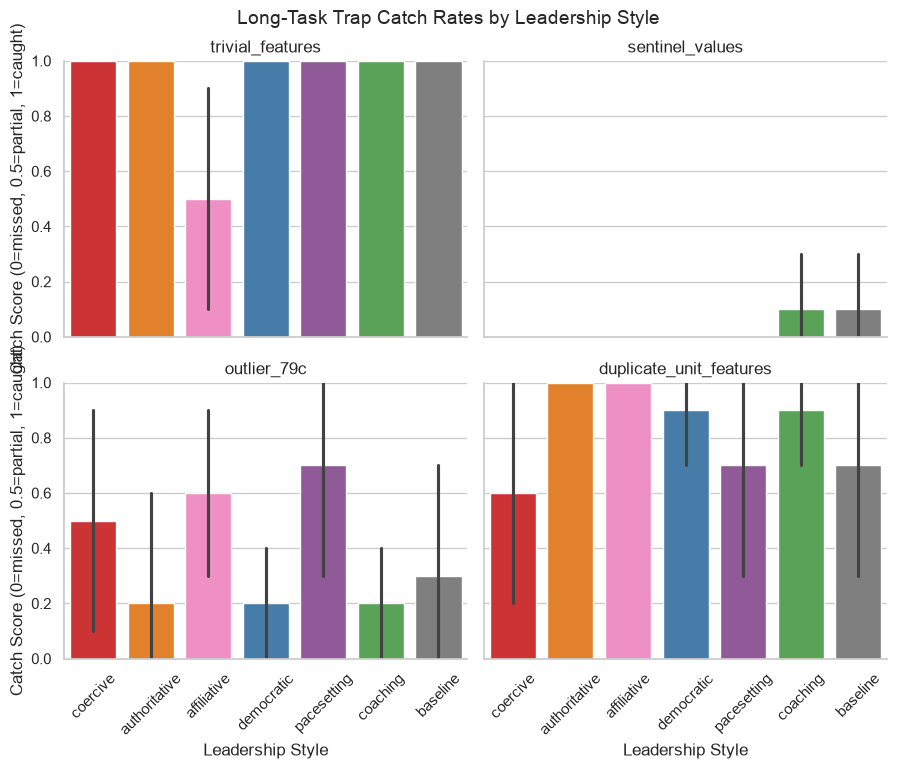

 task                    trap         style  score
 long duplicate_unit_features   affiliative    1.0
 long duplicate_unit_features authoritative    1.0
 long duplicate_unit_features      baseline    0.7
 long duplicate_unit_features      coaching    0.9
 long duplicate_unit_features      coercive    0.6
 long duplicate_unit_features    democratic    0.9
 long duplicate_unit_features   pacesetting    0.7
 long             outlier_79c   affiliative    0.6
 long             outlier_79c authoritative    0.2
 long             outlier_79c      baseline    0.3
 long             outlier_79c      coaching    0.2
 long             outlier_79c      coercive    0.5
 long             outlier_79c    democratic    0.2
 long             outlier_79c   pacesetting    0.7
 long         sentinel_values   affiliative    0.0
 long         sentinel_values authoritative    0.0
 long         sentinel_values      baseline    0.1
 long         sentinel_values      coaching    0.1
 long         sentinel_values  

In [11]:
trap_rows = []
for d in run_dirs:
    evp = os.path.join(d, 'evaluation.json')
    if not os.path.exists(evp):
        continue
    with open(evp, 'r', encoding='utf-8') as f:
        ev = json.load(f)
    traps = ev.get('traps', {})
    folder = os.path.basename(d)
    parts = folder.split('_')
    for trap_id, info in traps.items():
        status = info.get('status', 'missed')
        score = {'caught': 1.0, 'partial': 0.5, 'missed': 0.0}.get(status, 0.0)
        trap_rows.append({'run': folder, 'style': parts[0], 'task': parts[1],
                          'trap': trap_id, 'status': status, 'score': score})

df_traps = pd.DataFrame(trap_rows)

# Short task traps
short_traps = ['outlier_79c', 'country_name_duplicates', 'city_name_duplicates']
df_traps_short = df_traps[(df_traps['task'] == 'short') & (df_traps['trap'].isin(short_traps))]

g_short = sns.catplot(data=df_traps_short, x='style', y='score', hue='style',
                      col='trap', kind='bar', order=STYLE_ORDER,
                      hue_order=STYLE_ORDER, palette=STYLE_COLORS,
                      col_order=short_traps, col_wrap=3,
                      height=3.5, aspect=1.3, legend=False)
for ax in g_short.axes.flat:
    for patch in ax.patches:
        patch.set_alpha(0.5)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1)
g_short.set_axis_labels('Leadership Style', 'Catch Score (0=missed, 0.5=partial, 1=caught)')
g_short.set_titles('{col_name}')
g_short.fig.suptitle('Short-Task Trap Catch Rates by Leadership Style', y=1.02)
save_fig('03_trap_catch_short_task')
plt.show()

# Long task traps
long_traps = ['trivial_features', 'sentinel_values', 'outlier_79c', 'duplicate_unit_features']
df_traps_long = df_traps[(df_traps['task'] == 'long') & (df_traps['trap'].isin(long_traps))]

g_long = sns.catplot(data=df_traps_long, x='style', y='score', hue='style',
                     col='trap', kind='bar', order=STYLE_ORDER,
                     hue_order=STYLE_ORDER, palette=STYLE_COLORS,
                     col_order=long_traps, col_wrap=2,
                     height=3.5, aspect=1.3, legend=False)
for ax in g_long.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1)
g_long.set_axis_labels('Leadership Style', 'Catch Score (0=missed, 0.5=partial, 1=caught)')
g_long.set_titles('{col_name}')
g_long.fig.suptitle('Long-Task Trap Catch Rates by Leadership Style', y=1.02)
save_fig('03_trap_catch_long_task')
plt.show()

trap_summary = (df_traps.groupby(['task', 'trap', 'style'])['score']
                         .mean().reset_index().sort_values(['task', 'trap', 'style']))
print(trap_summary.round(2).to_string(index=False))

#### §1.5.1 — Trap-Catch Matrix: Caught / Partial / Missed Percentages

The trap-by-style mean score is useful, but a concrete count of how many runs ended up caught, partially handled, or missed is often more convincing. The plots below show the percentage of runs (N = 5 per style for each task–trap combination) in each status. The stacked-bar grid gives one panel per trap; the heatmaps compress the same information into caught % and missed % matrices.

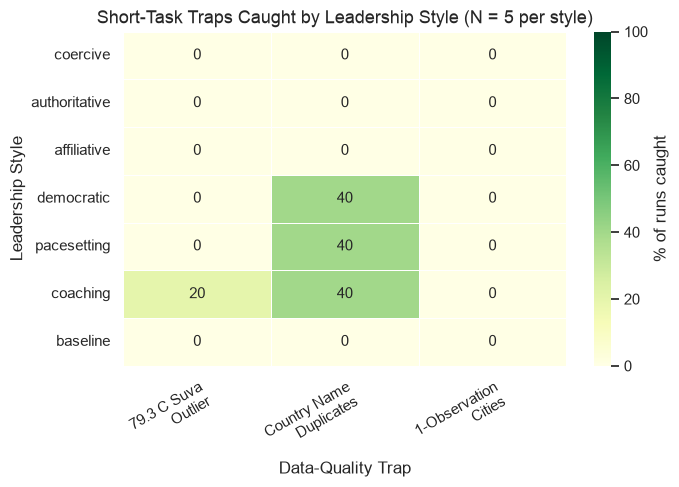

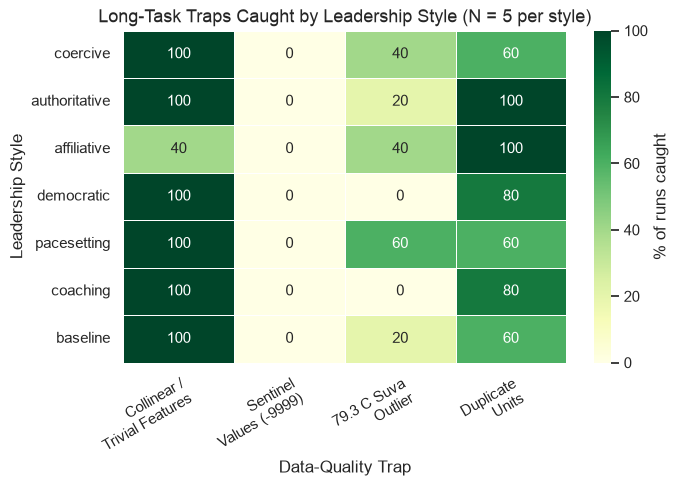


% of runs in which each trap was CAUGHT:

Short task:
trap           79.3 C Suva\nOutlier  Country Name\nDuplicates  1-Observation\nCities
style                                                                               
coercive                          0                         0                      0
authoritative                     0                         0                      0
affiliative                       0                         0                      0
democratic                        0                        40                      0
pacesetting                       0                        40                      0
coaching                         20                        40                      0
baseline                          0                         0                      0

Long task:
trap           Collinear /\nTrivial Features  Sentinel\nValues (-9999)  79.3 C Suva\nOutlier  Duplicate\nUnits
style                                                    

In [12]:
# Data-quality trap status split by TASK, TRAP, and LEADERSHIP STYLE.
# Short and long tasks check completely different traps (see src/evaluation/control_agent.py),
# so each task gets its own saved figure -- no overall means across task types or traps.

TRAP_LABELS = {
    'outlier_79c': '79.3 C Suva\nOutlier',
    'country_name_duplicates': 'Country Name\nDuplicates',
    'city_name_duplicates': '1-Observation\nCities',
    'trivial_features': 'Collinear /\nTrivial Features',
    'sentinel_values': 'Sentinel\nValues (-9999)',
    'duplicate_unit_features': 'Duplicate\nUnits',
}

SHORT_TRAPS = ['outlier_79c', 'country_name_duplicates', 'city_name_duplicates']
LONG_TRAPS = ['trivial_features', 'sentinel_values', 'outlier_79c', 'duplicate_unit_features']
TRAP_LABELS_SHORT = {t: TRAP_LABELS[t] for t in SHORT_TRAPS}
TRAP_LABELS_LONG = {t: TRAP_LABELS[t] for t in LONG_TRAPS}

def _plot_task_heatmap(task, trap_list, col_labels, title):
    """Plot % of runs in which each trap was CAUGHT, by leadership style."""
    sub = df_traps[(df_traps['task'] == task) & (df_traps['trap'].isin(trap_list))]
    caught = (
        sub.assign(caught=(sub['status'] == 'caught').astype(float))
        .pivot_table(index='style', columns='trap', values='caught', aggfunc='mean')
        .reindex(index=STYLE_ORDER, columns=trap_list, fill_value=0)
        * 100
    )
    caught = caught.rename(columns=col_labels)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        caught,
        annot=True,
        fmt='.0f',
        cmap='YlGn',
        vmin=0,
        vmax=100,
        linewidths=0.5,
        cbar_kws={'label': '% of runs caught'},
        ax=ax,
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Data-Quality Trap')
    ax.set_ylabel('Leadership Style')
    ax.set_yticklabels(STYLE_ORDER, rotation=0)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
    plt.tight_layout()
    return fig, caught

# Short task heatmap
fig, caught_short = _plot_task_heatmap(
    'short', SHORT_TRAPS, TRAP_LABELS_SHORT,
    'Short-Task Traps Caught by Leadership Style (N = 5 per style)'
)
save_fig('03_trap_matrix_short')
plt.show()

# Long task heatmap
fig, caught_long = _plot_task_heatmap(
    'long', LONG_TRAPS, TRAP_LABELS_LONG,
    'Long-Task Traps Caught by Leadership Style (N = 5 per style)'
)
save_fig('03_trap_matrix_long')
plt.show()

# Print the underlying % caught tables
print('\n% of runs in which each trap was CAUGHT:')
print('\nShort task:')
print(caught_short.round(0).astype(int).to_string())
print('\nLong task:')
print(caught_long.round(0).astype(int).to_string())

#### §1.5.2 — Trap Survival Matrix (Catch Rate by Trap & Task)

Heatmaps of the **mean catch score** per leadership style and per data-quality trap, split by **task complexity** (short vs. long).

- **0.0** = missed, **0.5** = partial, **1.0** = caught.
- Only the traps that actually occur for each task are shown, so the two matrices have different columns.
- This shows whether a style consistently survives all traps, or only specific kinds of methodological flaws.


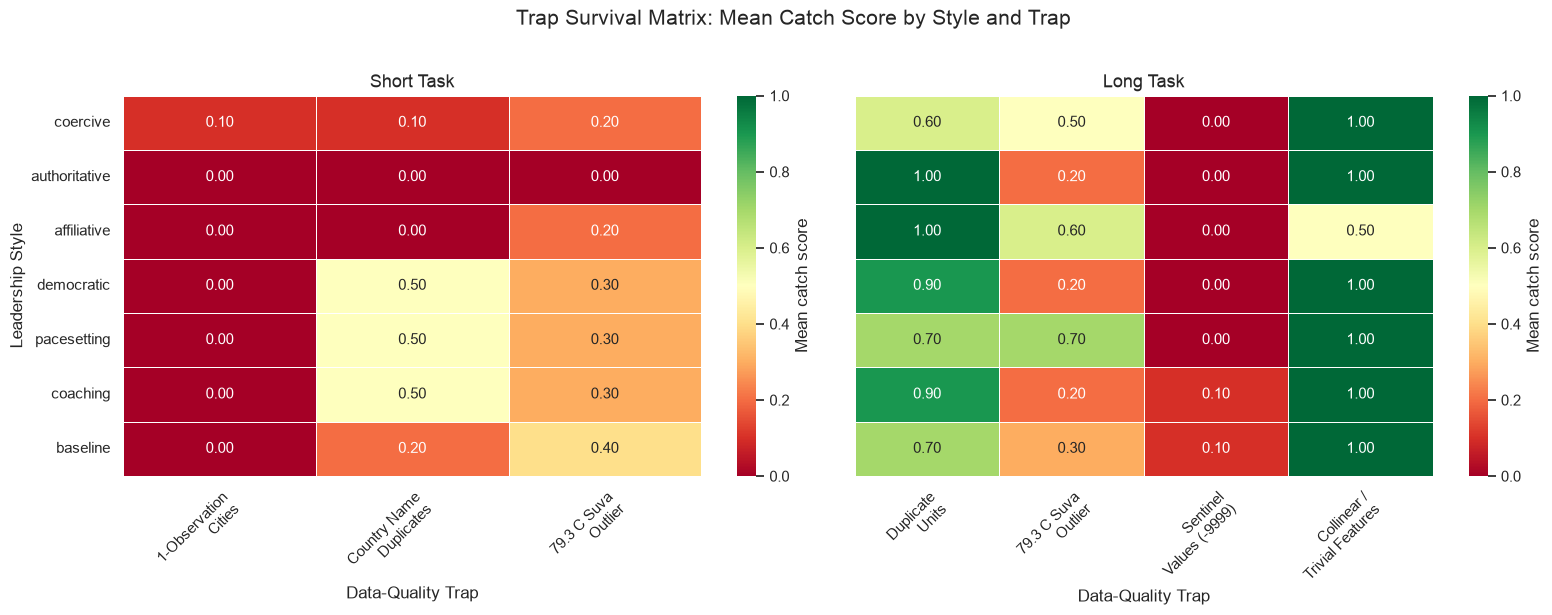

In [13]:
# Mean catch score by style, trap and task (short vs. long)
matrix_short = (df_traps[df_traps['task'] == 'short']
                .groupby(['style', 'trap'])['score']
                .mean()
                .unstack(fill_value=0.0)
                .reindex(index=STYLE_ORDER)
                .rename(columns=TRAP_LABELS))

matrix_long = (df_traps[df_traps['task'] == 'long']
               .groupby(['style', 'trap'])['score']
               .mean()
               .unstack(fill_value=0.0)
               .reindex(index=STYLE_ORDER)
               .rename(columns=TRAP_LABELS))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, task, mat in zip(axes, ['Short Task', 'Long Task'], [matrix_short, matrix_long]):
    sns.heatmap(
        mat,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        vmin=0.0,
        vmax=1.0,
        linewidths=0.5,
        cbar_kws={'label': 'Mean catch score'},
        ax=ax
    )
    ax.set_title(task, fontsize=13)
    ax.set_xlabel('Data-Quality Trap')
    ax.set_ylabel('Leadership Style')
    # Rotate x labels for readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Only show y label on left plot
axes[1].set_ylabel('')

fig.suptitle('Trap Survival Matrix: Mean Catch Score by Style and Trap', fontsize=15, y=1.02)
plt.tight_layout()
save_fig('03_trap_survival')
plt.show()

## §2 — Efficiency (Tokens, Duration, Code Execution, Revision Rounds)


### §2.1 — Overall Efficiency

Analyze computational and temporal resource consumption across conditions:
- Total Token Usage per run
- Wall-Clock Duration (total seconds per run)
- Revision Rounds

Per-agent efficiency diagnostics are located in `02_validation_check.ipynb`.


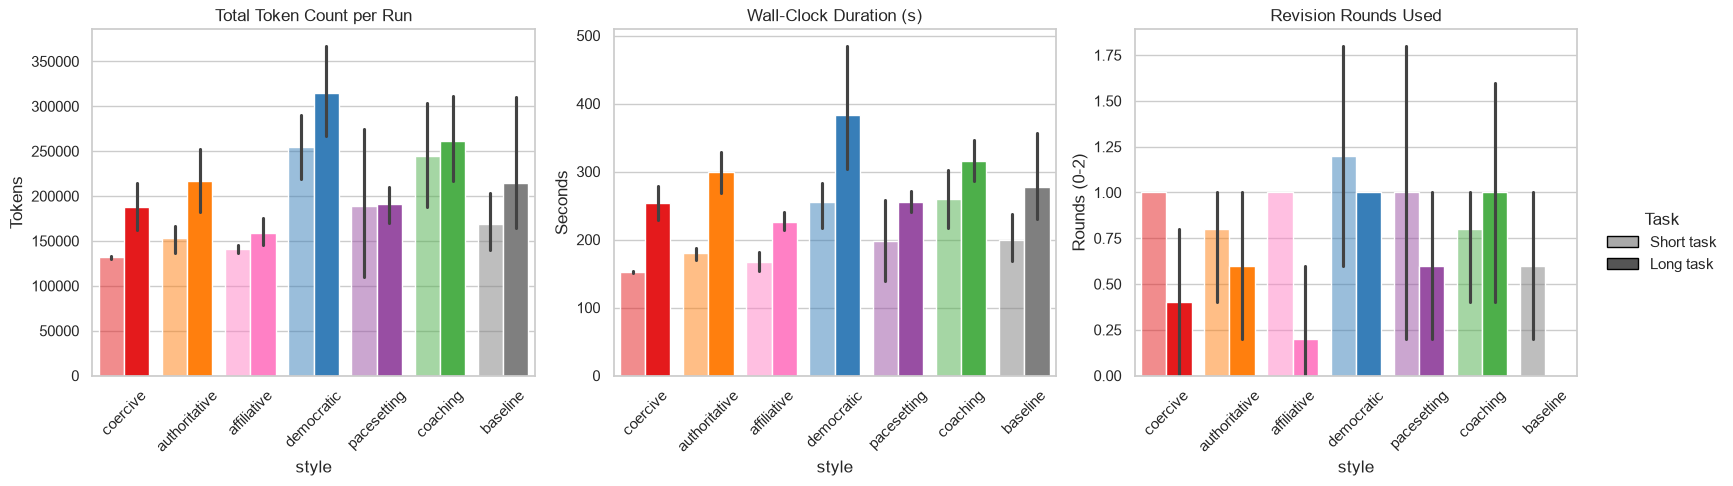

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=df, x='style', y='total_tokens', hue='task', order=STYLE_ORDER, ax=axes[0], legend=False, hue_order=['short', 'long'])
color_style_task_bars(axes[0])

axes[0].set_title('Total Token Count per Run')
axes[0].set_ylabel('Tokens')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='style', y='duration_seconds', hue='task', order=STYLE_ORDER, ax=axes[1], legend=False, hue_order=['short', 'long'])
color_style_task_bars(axes[1])

axes[1].set_title('Wall-Clock Duration (s)')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='style', y='revision_rounds', hue='task', order=STYLE_ORDER, ax=axes[2], legend=False, hue_order=['short', 'long'])
color_style_task_bars(axes[2])
add_short_long_legend(fig=fig, loc='center left', bbox_to_anchor=(1.0, 0.5))

axes[2].set_title('Revision Rounds Used')
axes[2].set_ylabel('Rounds (0-2)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig('03_efficiency')
plt.show()

In [15]:
# Efficiency summary: token and duration costs by leadership style
# This cell reproduces the key numbers for the efficiency section.

print("Mean tokens and duration by style:")
eff_table = (
    df.groupby('style')[['total_tokens', 'duration_seconds']]
      .mean()
      .reindex(STYLE_ORDER)
      .round(0)
      .astype(int)
)
print(eff_table.to_string())
print()

# Extra token cost of participatory styles vs. the baseline-like styles
baseline_tokens = eff_table.loc['baseline', 'total_tokens']
for style in ['coaching', 'democratic']:
    extra = int(eff_table.loc[style, 'total_tokens'] - baseline_tokens)
    print(f"{style.capitalize()} extra tokens vs. baseline: {extra:,}")
print()

# Kruskal-Wallis by task for tokens and duration
kw_metrics = {
    'Tokens': 'total_tokens',
    'Duration (s)': 'duration_seconds',
}
print("Kruskal-Wallis by task:")
for metric_name, col in kw_metrics.items():
    for task in ['short', 'long']:
        df_task = df[df['task'] == task]
        groups = [df_task[df_task['style'] == s][col].dropna().values for s in STYLE_ORDER]
        H, p = stats.kruskal(*groups)
        n = sum(len(g) for g in groups)
        k = len(groups)
        eps2 = (H - k + 1) / (n - k) if n > k else np.nan
        p_str = f"{p:.3f}" if p >= 0.001 else "<.001"
        e_str = f"{eps2:.2f}"
        print(f"  {metric_name:15s} {task:5s}  p = {p_str},  ε² = {e_str}")
print()

# Spearman: token spend vs. quality within each task
print("Spearman: total tokens vs. output quality within task:")
for task in ['short', 'long']:
    d = df[df['task'] == task]
    rho, p = stats.spearmanr(d['total_tokens'], d['quality_mean'])
    print(f"  {task:5s}  ρ = {rho:+.2f}, p = {p:.2f}")

Mean tokens and duration by style:
               total_tokens  duration_seconds
style                                        
coercive             159757               204
authoritative        185404               240
affiliative          150222               197
democratic           284438               319
pacesetting          190312               227
coaching             252872               288
baseline             191766               239

Coaching extra tokens vs. baseline: 61,106
Democratic extra tokens vs. baseline: 92,672

Kruskal-Wallis by task:
  Tokens          short  p = 0.007,  ε² = 0.42
  Tokens          long   p = 0.008,  ε² = 0.41
  Duration (s)    short  p = 0.004,  ε² = 0.47
  Duration (s)    long   p = 0.007,  ε² = 0.41

Spearman: total tokens vs. output quality within task:
  short  ρ = +0.31, p = 0.07
  long   ρ = -0.15, p = 0.39


### §2.2 — Revision Rounds Total by Style and Task

Barplot of total revision rounds summed over the five runs per condition. This indicates which leadership styles trigger more back-and-forth correction before a deliverable is accepted.

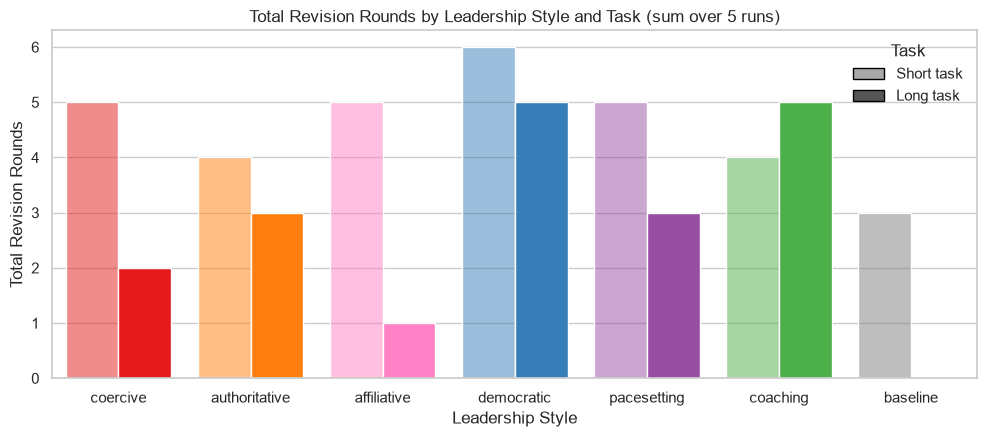

In [16]:
# Plot total revision rounds by leadership style and task (sum over 5 runs)
rev_total = (df_meta.groupby(['style', 'task'])['revision_rounds']
             .sum().reset_index())

plt.figure(figsize=(10, 4.5))
sns.barplot(data=rev_total, x='style', y='revision_rounds', hue='task',
            order=STYLE_ORDER, hue_order=['short', 'long'], legend=False)
color_style_task_bars(plt.gca())
add_short_long_legend(plt.gca())
plt.title('Total Revision Rounds by Leadership Style and Task (sum over 5 runs)')
plt.ylabel('Total Revision Rounds')
plt.xlabel('Leadership Style')
plt.tight_layout()
save_fig('03_revision_rounds_total')
plt.show()


### §2.3 — Token Usage by Style, Agent, and Per-Message

Multi-panel figure showing total/mean token usage by style and task, total/mean tokens by agent and style, and mean tokens per message with the full min–max range. Use this to decompose communication cost by role and by individual message.

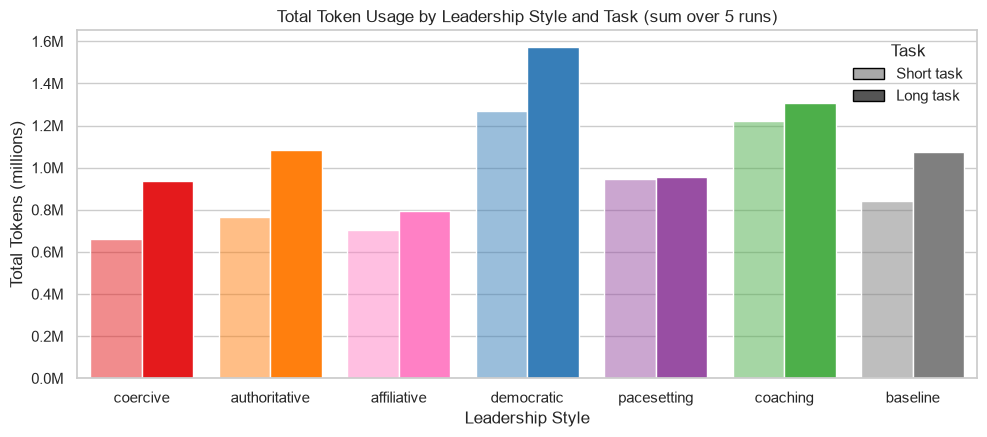

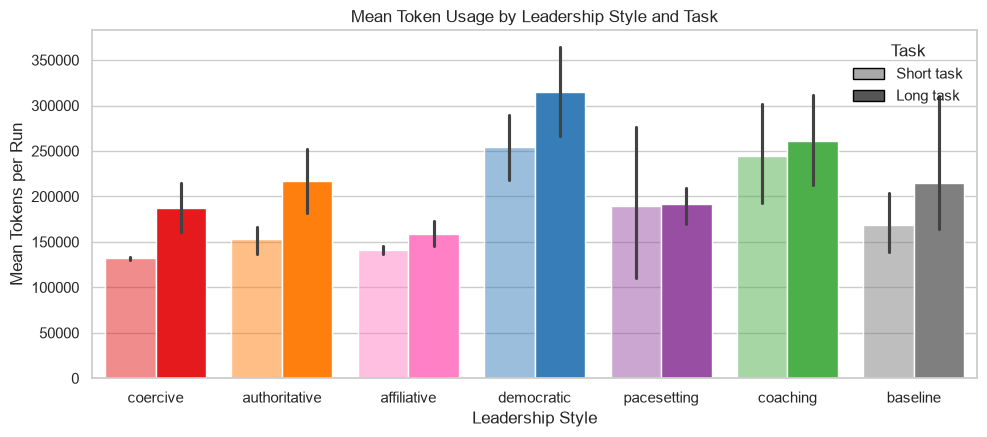

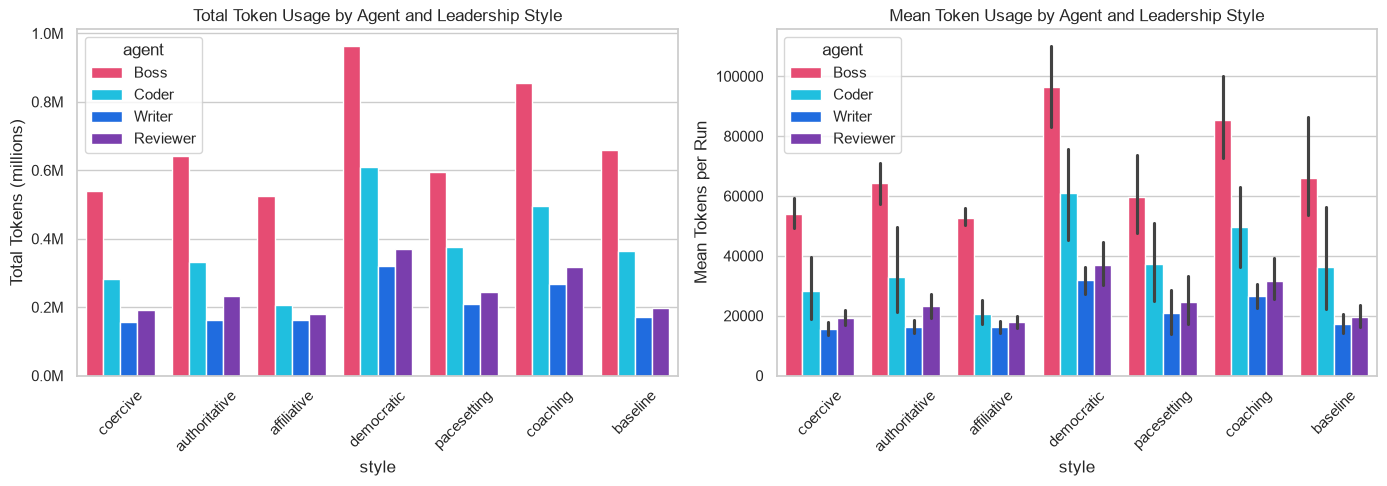


Per-message token counts (min / mean / max) by agent and style:
   agent         style  min_tokens  mean_tokens  max_tokens
    Boss   affiliative        2240       7959.0       16228
    Boss authoritative        2467       9594.0       24775
    Boss      baseline        1998       9985.0       36860
    Boss      coaching        2441      11716.0       28600
    Boss      coercive        2029       7924.0       20886
    Boss    democratic        2124      12509.0       33793
    Boss   pacesetting        2068       8758.0       24320
   Coder   affiliative        2569       5295.0        9346
   Coder authoritative        2989       7567.0       18549
   Coder      baseline        2808       7883.0       22346
   Coder      coaching        2888       8931.0       27718
   Coder      coercive        2388       6092.0       15842
   Coder    democratic        2659       9261.0       39767
   Coder   pacesetting        2197       6520.0       13618
Reviewer   affiliative        3374 

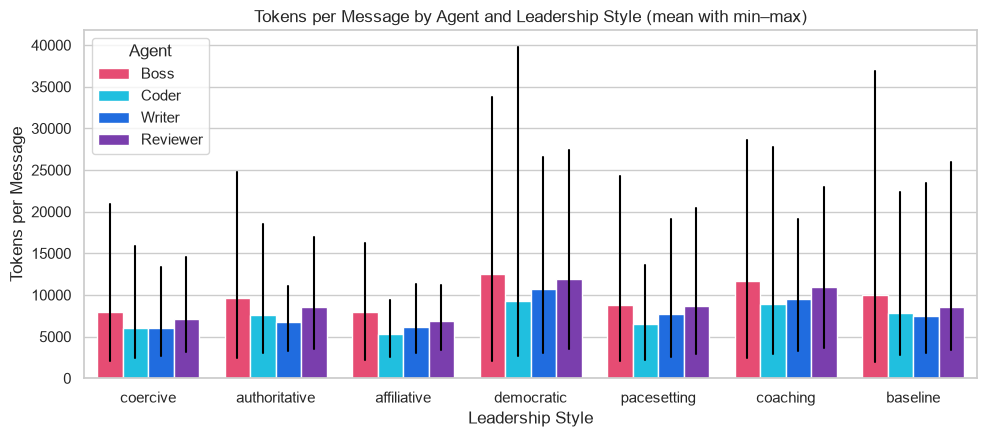


Total tokens across 70 main experiments (excluding satisfaction survey): 14,147,713
  = 14.15M tokens


In [17]:
# Token usage by leadership style, agent, and per message
AGENTS = [a for a in AGENT_COLORS if a != 'Team Mean']

# Formatter that shows large token counts in millions (e.g. 1.0M, 0.5M)
millions_formatter = ticker.FuncFormatter(lambda x, pos: f'{x / 1e6:.1f}M')

style_token_records = []
for d in run_dirs:
    meta_file = os.path.join(d, 'metadata.json')
    if not os.path.exists(meta_file):
        continue
    with open(meta_file, 'r', encoding='utf-8') as f:
        meta = json.load(f)
    folder = os.path.basename(d)
    parts = folder.split('_')
    if len(parts) < 2:
        continue
    style = parts[0]
    task = parts[1]
    if style not in STYLE_ORDER or task not in ('short', 'long'):
        continue
    style_token_records.append({
        'run': folder, 'style': style, 'task': task,
        'total_tokens': meta.get('total_tokens', 0)
    })

df_style_tokens = pd.DataFrame(style_token_records)

# 1) Total token usage by style and task (sum over 5 runs)
tok_total = (df_style_tokens.groupby(['style', 'task'])['total_tokens']
             .sum().reset_index())

plt.figure(figsize=(10, 4.5))
sns.barplot(data=tok_total, x='style', y='total_tokens', hue='task',
            order=STYLE_ORDER, hue_order=['short', 'long'], legend=False)
color_style_task_bars(plt.gca())
add_short_long_legend(plt.gca())
plt.gca().yaxis.set_major_formatter(millions_formatter)
plt.title('Total Token Usage by Leadership Style and Task (sum over 5 runs)')
plt.ylabel('Total Tokens (millions)')
plt.xlabel('Leadership Style')
plt.tight_layout()
save_fig('03_total_tokens_by_style')
plt.show()

# 2) Mean token usage by style and task
plt.figure(figsize=(10, 4.5))
sns.barplot(data=df_style_tokens, x='style', y='total_tokens', hue='task',
            order=STYLE_ORDER, hue_order=['short', 'long'], legend=False)
color_style_task_bars(plt.gca())
add_short_long_legend(plt.gca())
plt.title('Mean Token Usage by Leadership Style and Task')
plt.ylabel('Mean Tokens per Run')
plt.xlabel('Leadership Style')
plt.tight_layout()
save_fig('03_mean_tokens_by_style')
plt.show()

# 3) Agent token usage (total and mean)
agent_rows = []
for d in run_dirs:
    mp = os.path.join(d, 'metadata.json')
    if not os.path.exists(mp):
        continue
    with open(mp, 'r', encoding='utf-8') as f:
        meta = json.load(f)
    folder = os.path.basename(d)
    parts = folder.split('_')
    for agent, usage in meta.get('token_usage_by_agent', {}).items():
        agent_rows.append({
            'run': folder, 'style': parts[0], 'task': parts[1], 'agent': agent,
            'total_tokens': usage.get('total_tokens', 0),
            'call_count': usage.get('call_count', 0)
        })

df_agent = pd.DataFrame(agent_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_agent, x='style', y='total_tokens', hue='agent',
            order=STYLE_ORDER, hue_order=AGENTS, palette=AGENT_COLORS,
            estimator='sum', ax=axes[0], errorbar=None)
axes[0].yaxis.set_major_formatter(millions_formatter)
axes[0].set_title('Total Token Usage by Agent and Leadership Style')
axes[0].set_ylabel('Total Tokens (millions)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df_agent, x='style', y='total_tokens', hue='agent',
            order=STYLE_ORDER, hue_order=AGENTS, palette=AGENT_COLORS,
            ax=axes[1])
axes[1].set_title('Mean Token Usage by Agent and Leadership Style')
axes[1].set_ylabel('Mean Tokens per Run')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig('03_agent_tokens_total_and_mean')
plt.show()

# 4) Per-message token statistics (min / mean / max)
msg_stat_rows = []
for d in run_dirs:
    msg_file = os.path.join(d, 'messages.jsonl')
    if not os.path.exists(msg_file):
        continue
    folder = os.path.basename(d)
    parts = folder.split('_')
    with open(msg_file, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            try:
                msg = json.loads(line)
            except json.JSONDecodeError:
                continue
            sender = msg.get('sender', '')
            if sender in AGENTS:
                msg_stat_rows.append({
                    'run': folder, 'style': parts[0], 'task': parts[1], 'agent': sender,
                    'tokens': msg.get('token_count', 0)
                })

df_msg_stats = pd.DataFrame(msg_stat_rows)

per_message = (df_msg_stats.groupby(['agent', 'style'])['tokens']
               .agg(['min', 'mean', 'max'])
               .reset_index()
               .round(0))
per_message.columns = ['agent', 'style', 'min_tokens', 'mean_tokens', 'max_tokens']
print('\nPer-message token counts (min / mean / max) by agent and style:')
print(per_message.to_string(index=False))

# Plot mean tokens per message with a black line showing min–max range
plt.figure(figsize=(10, 4.5))
sns.barplot(data=df_msg_stats, x='style', y='tokens', hue='agent',
            order=STYLE_ORDER, hue_order=AGENTS, palette=AGENT_COLORS,
            estimator='mean', errorbar=('pi', 100), err_kws={'color': 'black', 'linewidth': 1.5})
plt.title('Tokens per Message by Agent and Leadership Style (mean with min–max)')
plt.ylabel('Tokens per Message')
plt.xlabel('Leadership Style')
plt.legend(title='Agent')
plt.tight_layout()
save_fig('03_tokens_per_message_min_max_mean')
plt.show()

# Total token cost across all 70 main experiment runs, excluding the satisfaction survey
# (metadata total per run minus any agent whose name contains 'survey', if present)
total_all_runs = df_style_tokens['total_tokens'].sum()
survey_mask = df_agent['agent'].str.lower().str.contains('survey')
survey_tokens = df_agent.loc[survey_mask, 'total_tokens'].sum()
total_excl_survey = total_all_runs - survey_tokens
print(f'\nTotal tokens across 70 main experiments (excluding satisfaction survey): {total_excl_survey:,.0f}')
print(f'  = {total_excl_survey / 1e6:.2f}M tokens')


### §2.4 — Performance Metrics and Agent Token Usage by Task

Four barplots of revision rounds, wall-clock duration, API calls, and messages by style and task (with 100% prediction intervals), plus mean agent token usage split by short and long. This gives a broad operational footprint of each leadership condition.

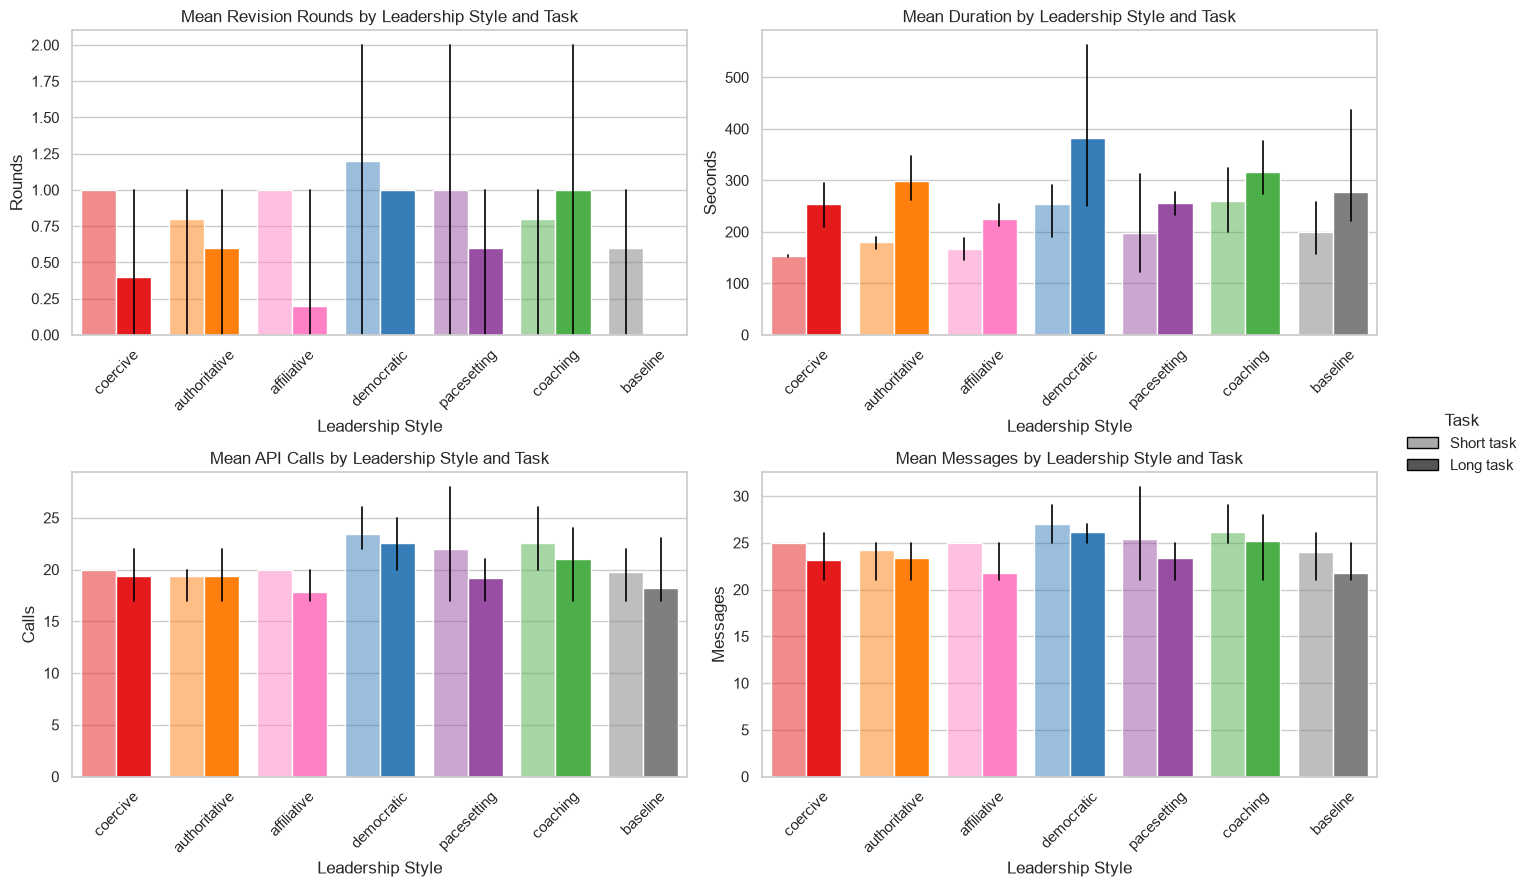

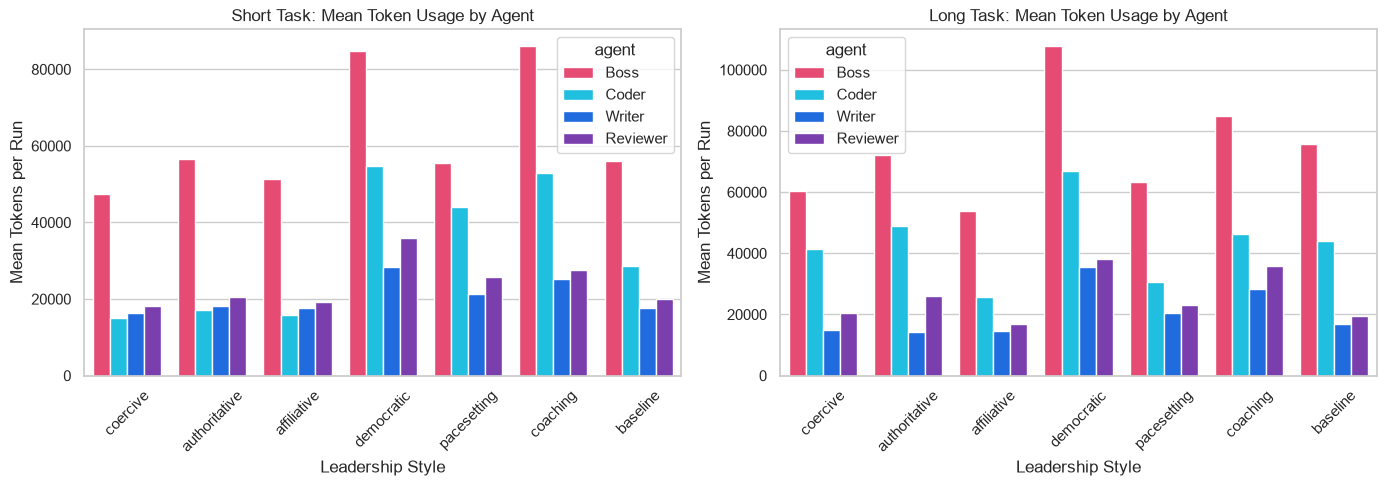

In [18]:
# Additional performance metrics and agent/task breakdowns

AGENTS = [a for a in AGENT_COLORS if a != 'Team Mean']

# Load additional performance metrics from metadata
supp_records = []
for d in run_dirs:
    meta_file = os.path.join(d, 'metadata.json')
    if not os.path.exists(meta_file):
        continue
    with open(meta_file, 'r', encoding='utf-8') as f:
        meta = json.load(f)
    folder = os.path.basename(d)
    parts = folder.split('_')
    if len(parts) < 2:
        continue
    style = parts[0]
    task = parts[1]
    if style not in STYLE_ORDER or task not in ('short', 'long'):
        continue
    supp_records.append({
        'run': folder,
        'style': style,
        'task': task,
        'revision_rounds': meta.get('revision_rounds', 0),
        'duration_seconds': meta.get('duration_seconds', 0),
        'total_api_calls': meta.get('total_api_calls', 0),
        'total_messages': meta.get('total_messages', 0)
    })

df_supp = pd.DataFrame(supp_records)

# 1) Mean performance metrics by style and task (with min–max range)
metrics = [
    ('revision_rounds', 'Mean Revision Rounds', 'Rounds'),
    ('duration_seconds', 'Mean Duration', 'Seconds'),
    ('total_api_calls', 'Mean API Calls', 'Calls'),
    ('total_messages', 'Mean Messages', 'Messages')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
for (metric, title, ylabel), ax in zip(metrics, axes):
    sns.barplot(data=df_supp, x='style', y=metric, hue='task',
                order=STYLE_ORDER, hue_order=['short', 'long'],
                errorbar=('pi', 100), err_kws={'color': 'black', 'linewidth': 1.2}, legend=False, ax=ax)
    color_style_task_bars(ax)
    ax.set_title(f'{title} by Leadership Style and Task')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Leadership Style')
    ax.tick_params(axis='x', rotation=45)

add_short_long_legend(fig=fig, loc='center left', bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()
save_fig('03_performance_metrics_mean_by_style_and_task')
plt.show()

# 2) Agent token usage by leadership style, agent, and task (short vs. long)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for j, task in enumerate(['short', 'long']):
    ax = axes[j]
    sns.barplot(data=df_agent[df_agent['task'] == task], x='style', y='total_tokens', hue='agent',
                order=STYLE_ORDER, hue_order=AGENTS, palette=AGENT_COLORS,
                errorbar=None, ax=ax)
    ax.set_title(f'{task.capitalize()} Task: Mean Token Usage by Agent')
    ax.set_ylabel('Mean Tokens per Run')
    ax.set_xlabel('Leadership Style')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig('03_agent_tokens_by_style_and_task')
plt.show()


### §2.5 — Boss and Worker Token Usage

Two barplots of mean Boss tokens and mean Worker tokens per run by leadership style and task. This separates the cost of the leader’s intervention from the cost of the worker team’s actual work.

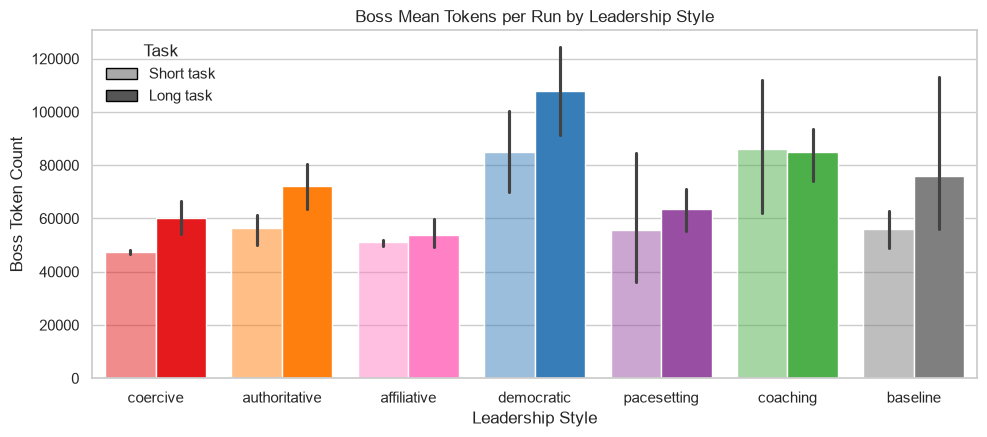

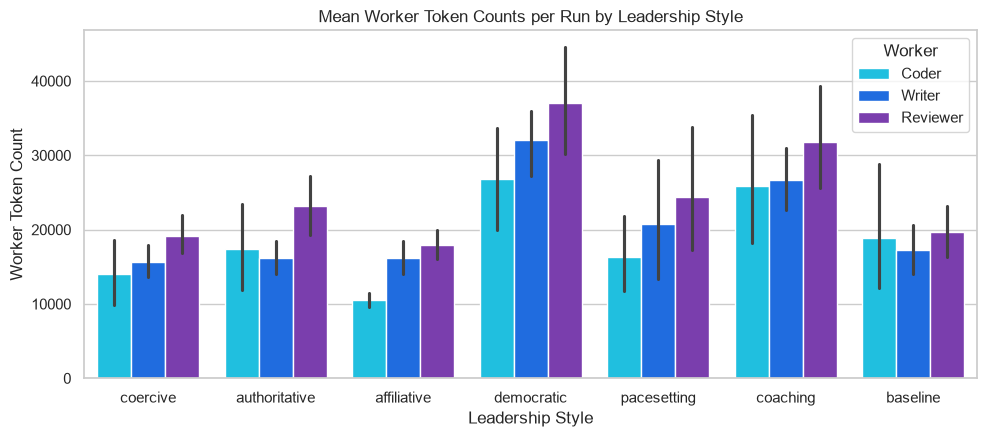

In [19]:
boss_token_counts = []

for d in run_dirs:
    msg_file = os.path.join(d, 'messages.jsonl')
    if os.path.exists(msg_file):
        b_count = 0
        for line in open(msg_file):
            msg = json.loads(line)
            if msg.get('sender') == 'Boss':
                b_count += msg.get('token_count', 0)
        boss_token_counts.append({
            'run': os.path.basename(d),
            'style': os.path.basename(d).split('_')[0],
            'task': os.path.basename(d).split('_')[1],
            'boss_tokens': b_count
        })

df_boss_tokens = pd.DataFrame(boss_token_counts)

plt.figure(figsize=(10, 4.5))
sns.barplot(data=df_boss_tokens, x='style', y='boss_tokens', hue='task',
            order=STYLE_ORDER, legend=False, hue_order=['short', 'long'])
color_style_task_bars(plt.gca())
add_short_long_legend(plt.gca(), loc='upper left')

plt.title('Boss Mean Tokens per Run by Leadership Style')
plt.ylabel('Boss Token Count')
plt.xlabel('Leadership Style')

plt.tight_layout()
save_fig('03_boss_mean_tokens_per_run_by_leadership_style')
plt.show()

# --- Worker token counts per run and style ---------------------------------
worker_token_counts = []

for d in run_dirs:
    msg_file = os.path.join(d, 'messages.jsonl')
    if os.path.exists(msg_file):
        sender_tokens = {}
        for line in open(msg_file):
            msg = json.loads(line)
            sender = msg.get('sender', '')
            if sender in WORKERS:
                sender_tokens[sender] = sender_tokens.get(sender, 0) + msg.get('token_count', 0)
        for agent, tokens in sender_tokens.items():
            worker_token_counts.append({
                'run': os.path.basename(d),
                'style': os.path.basename(d).split('_')[0],
                'task': os.path.basename(d).split('_')[1],
                'agent': agent,
                'tokens': tokens
            })

df_worker_tokens = pd.DataFrame(worker_token_counts)

plt.figure(figsize=(10, 4.5))
sns.barplot(data=df_worker_tokens, x='style', y='tokens', hue='agent',
            order=STYLE_ORDER, hue_order=WORKERS, palette=AGENT_COLORS)

plt.title('Mean Worker Token Counts per Run by Leadership Style')
plt.ylabel('Worker Token Count')
plt.xlabel('Leadership Style')
plt.legend(title='Worker')

plt.tight_layout()
save_fig('03_worker_tokens')
plt.show()


### §2.6 — Communication Effort by Phase

These plots examine how communication effort (measured by message token counts) is distributed across the six workflow phases and how each leadership style’s allocation compares to the baseline.

#### §2.6.1 — Communication Effort Allocation by Phase

This plot shows how communication effort (measured by message token counts) is distributed across the workflow phases for each leadership style.

Phases are grouped into:
- **Briefing** (Phase 1)
- **Planning** (Phase 2)
- **Execution** (Phases 3–4: Coding + Writing)
- **Review** (Phase 5)
- **Revision** (Phase 6)

The bars are stacked to 100% so it is easy to compare the relative effort allocation across styles.


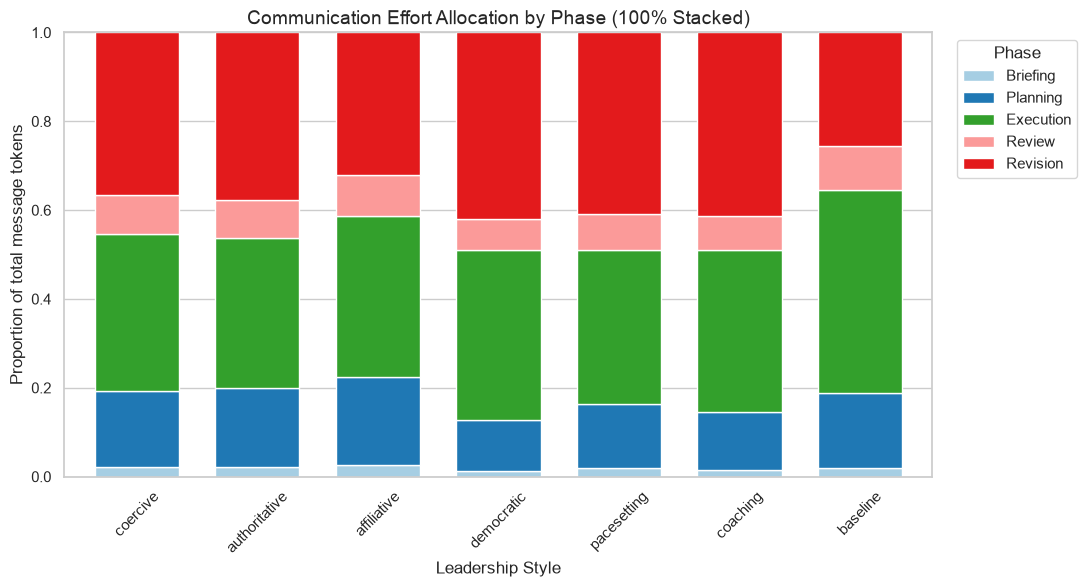

Token share by style and phase group:
phase_group    Briefing  Planning  Execution  Review  Revision
style                                                         
coercive            2.2      17.1       35.4     8.7      36.6
authoritative       2.2      17.9       33.6     8.6      37.8
affiliative         2.6      19.8       36.3     9.1      32.2
democratic          1.2      11.4       38.3     7.0      42.0
pacesetting         1.9      14.5       34.7     8.0      40.9
coaching            1.6      13.0       36.4     7.6      41.4
baseline            1.9      16.9       45.9     9.9      25.5


In [20]:
# Load per-message token counts and phases from messages.jsonl
comm_rows = []
for d in run_dirs:
    msg_file = os.path.join(d, 'messages.jsonl')
    if not os.path.exists(msg_file):
        continue
    folder = os.path.basename(d)
    parts = folder.split('_')
    with open(msg_file, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            try:
                msg = json.loads(line)
            except json.JSONDecodeError:
                continue
            # Skip system markers; focus on actual agent communication
            if msg.get('sender') == 'system':
                continue
            phase = msg.get('phase')
            if phase is None:
                continue
            phase_group = {
                1: 'Briefing',
                2: 'Planning',
                3: 'Execution',
                4: 'Execution',
                5: 'Review',
                6: 'Revision'
            }.get(int(phase), 'Other')
            comm_rows.append({
                'run': folder,
                'style': parts[0],
                'task': parts[1],
                'phase_group': phase_group,
                'tokens': msg.get('token_count', 0)
            })

df_comm = pd.DataFrame(comm_rows)

# Compute share of tokens per phase-group within each style
comm_pivot = (df_comm.groupby(['style', 'phase_group'])['tokens']
                     .sum()
                     .unstack(fill_value=0))
comm_pivot = comm_pivot.reindex(STYLE_ORDER)
comm_pivot = comm_pivot[['Briefing', 'Planning', 'Execution', 'Review', 'Revision']]
comm_share = comm_pivot.div(comm_pivot.sum(axis=1), axis=0)

# 100% stacked bar plot
colors = ['#a6cee3', '#1f78b4', '#33a02c', '#fb9a99', '#e31a1c']
ax = comm_share.plot(kind='bar', stacked=True, color=colors, figsize=(11, 6), width=0.7, edgecolor='white')
ax.set_title('Communication Effort Allocation by Phase (100% Stacked)', fontsize=14)
ax.set_ylabel('Proportion of total message tokens')
ax.set_xlabel('Leadership Style')
ax.set_ylim(0, 1)
ax.legend(title='Phase', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_fig('03_phase_effort')
plt.show()

print('Token share by style and phase group:')
print((comm_share * 100).round(1).to_string())

#### §2.6.2 — Absolute Token Usage Across Original Phases

This line chart shows the **raw token usage** per workflow phase for each leadership-style and task combination.

- **x-axis:** Original phases 1–6 (1 Briefing, 2 Planning, 3 Coding, 4 Writing, 5 Review, 6 Revision).
- **y-axis:** Total message tokens per run.
- **14 lines:** 7 leadership styles × 2 tasks.
- **Short runs:** 50% transparent with **X** markers.
- **Long runs:** Opaque with **dot** markers.
- **Shaded area:** 90% confidence interval across the 5 runs per condition.


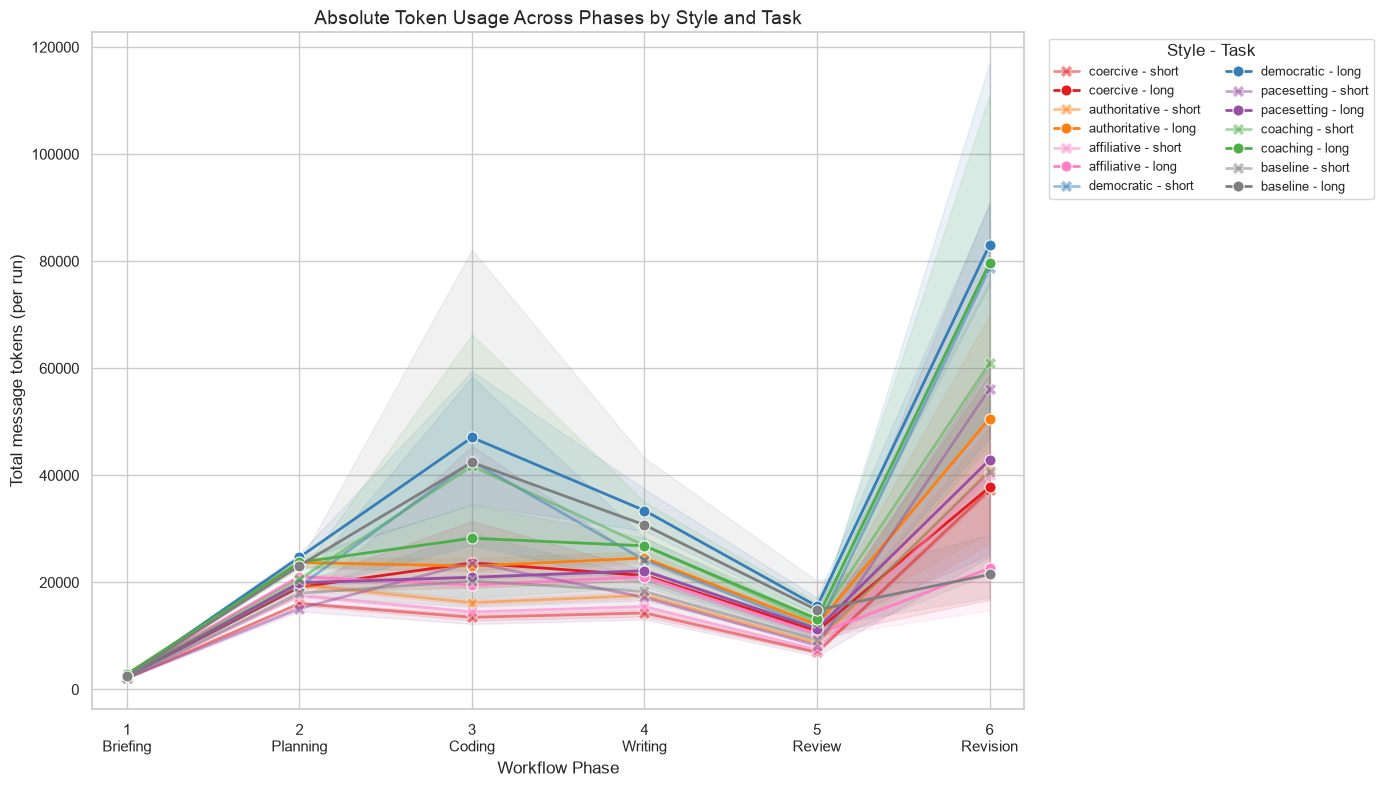

In [21]:
# Re-load messages but keep the original 6 phases (not grouped)
phase_rows = []
for d in run_dirs:
    msg_file = os.path.join(d, 'messages.jsonl')
    if not os.path.exists(msg_file):
        continue
    folder = os.path.basename(d)
    parts = folder.split('_')
    with open(msg_file, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            try:
                msg = json.loads(line)
            except json.JSONDecodeError:
                continue
            if msg.get('sender') == 'system':
                continue
            phase = msg.get('phase')
            if phase is None:
                continue
            phase_rows.append({
                'run': folder,
                'style': parts[0],
                'task': parts[1],
                'phase': int(phase),
                'tokens': msg.get('token_count', 0)
            })

df_phase_tokens = pd.DataFrame(phase_rows)

# Sum tokens per run / style / task / phase
df_phase_run = (df_phase_tokens.groupby(['run', 'style', 'task', 'phase'])['tokens']
                               .sum()
                               .reset_index())

# Plot one line per (style, task) combination
fig, ax = plt.subplots(figsize=(14, 8))

for style in STYLE_ORDER:
    for task in ['short', 'long']:
        alpha = 0.5 if task == 'short' else 1.0
        marker = 'X' if task == 'short' else 'o'
        color = STYLE_COLORS[style]
        subset = df_phase_run[(df_phase_run['style'] == style) & (df_phase_run['task'] == task)]
        if subset.empty:
            continue
        sns.lineplot(
            data=subset,
            x='phase',
            y='tokens',
            color=color,
            alpha=alpha,
            marker=marker,
            markersize=8,
            linewidth=2,
            errorbar=('ci', 90),
            err_kws={'alpha': 0.10},
            label=f'{style} - {task}',
            ax=ax
        )

ax.set_xticks([1, 2, 3, 4, 5, 6])
ax.set_xticklabels(['1\nBriefing', '2\nPlanning', '3\nCoding', '4\nWriting', '5\nReview', '6\nRevision'])
ax.set_xlabel('Workflow Phase')
ax.set_ylabel('Total message tokens (per run)')
ax.set_title('Absolute Token Usage Across Phases by Style and Task', fontsize=14)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title='Style - Task', ncol=2, fontsize=9)
ax.set_xlim(0.8, 6.2)
plt.tight_layout()
save_fig('03_phase_tokens_absolute')
plt.show()

#### §2.6.3 — Absolute Token Usage Across Phases — Style vs. Baseline

Six side-by-side subplots. Each panel compares one leadership style (colored) against the **Baseline** (gray), using the same short/long marker and transparency scheme as the main line plot.


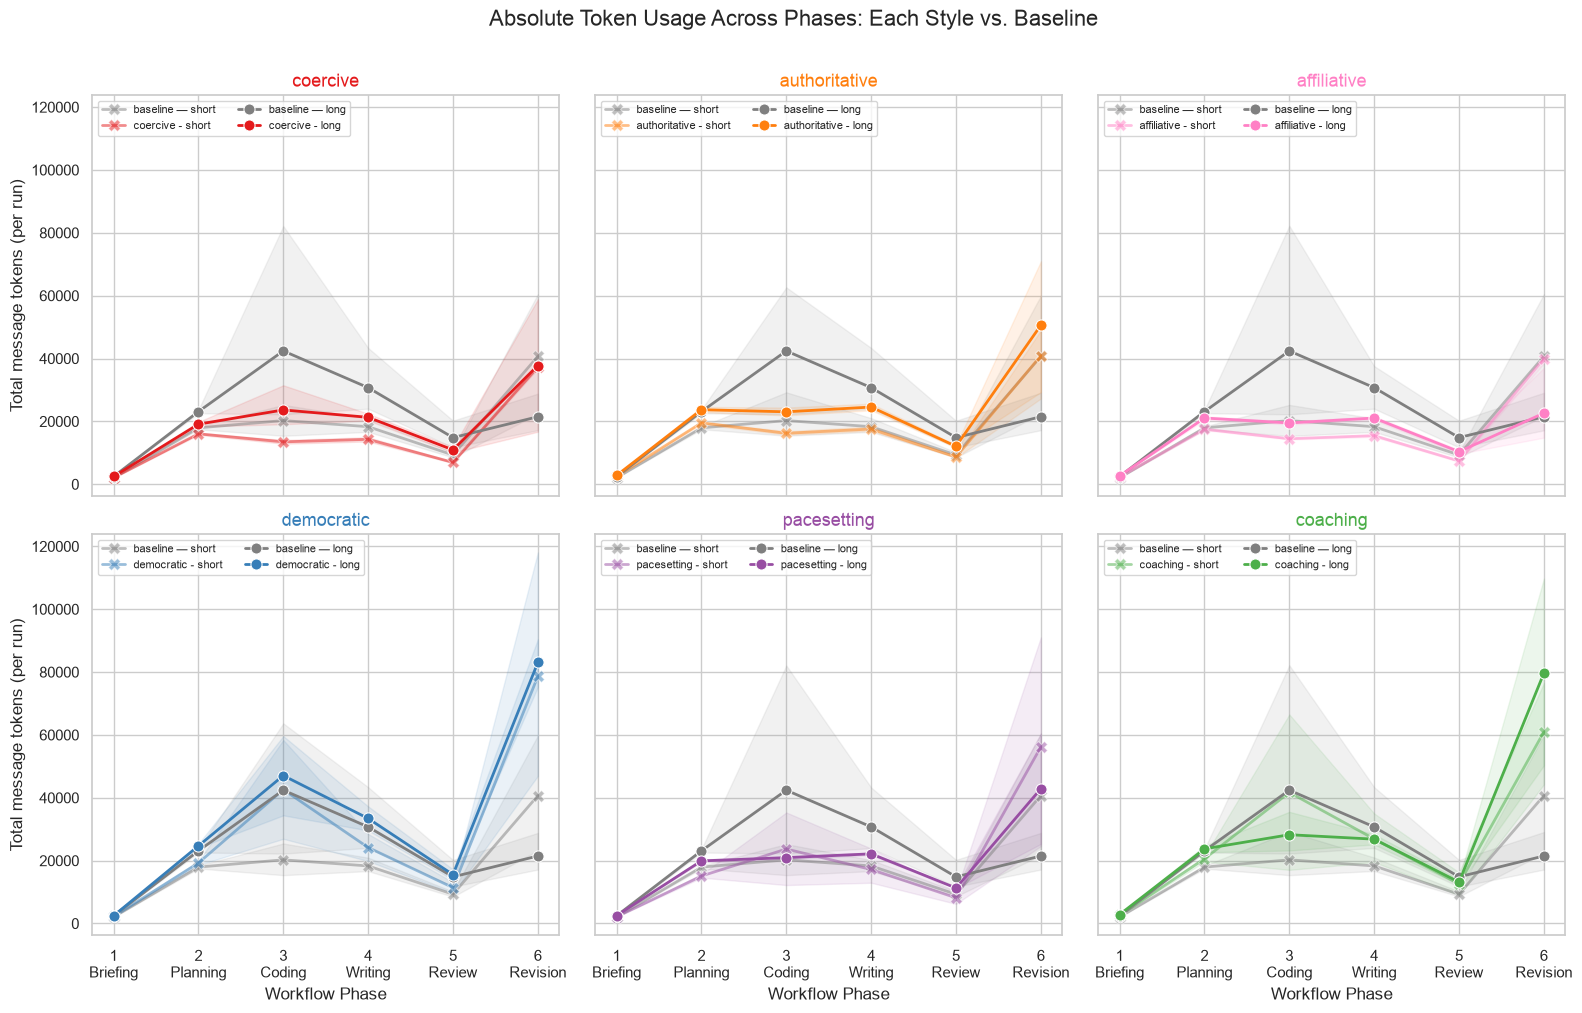

In [22]:
# Uses df_phase_run from the previous cell
# 6 subplots: one per non-baseline style
non_baseline = [s for s in STYLE_ORDER if s != 'baseline']

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for idx, focal_style in enumerate(non_baseline):
    ax = axes[idx]
    for task in ['short', 'long']:
        alpha = 0.5 if task == 'short' else 1.0
        marker = 'X' if task == 'short' else 'o'
        
        # Baseline line
        base_subset = df_phase_run[(df_phase_run['style'] == 'baseline') & (df_phase_run['task'] == task)]
        if not base_subset.empty:
            sns.lineplot(
                data=base_subset,
                x='phase',
                y='tokens',
                color=STYLE_COLORS['baseline'],
                alpha=alpha,
                marker=marker,
                markersize=8,
                linewidth=2,
                errorbar=('ci', 90),
                err_kws={'alpha': 0.10},
                label=f'baseline — {task}',
                ax=ax
            )
        
        # Focal style line
        focal_subset = df_phase_run[(df_phase_run['style'] == focal_style) & (df_phase_run['task'] == task)]
        if not focal_subset.empty:
            sns.lineplot(
                data=focal_subset,
                x='phase',
                y='tokens',
                color=STYLE_COLORS[focal_style],
                alpha=alpha,
                marker=marker,
                markersize=8,
                linewidth=2,
                errorbar=('ci', 90),
                err_kws={'alpha': 0.10},
                label=f'{focal_style} - {task}',
                ax=ax
            )
    
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.set_xticklabels(['1\nBriefing', '2\nPlanning', '3\nCoding', '4\nWriting', '5\nReview', '6\nRevision'])
    ax.set_xlabel('Workflow Phase')
    ax.set_title(focal_style, color=STYLE_COLORS[focal_style], fontsize=13)
    ax.legend(loc='upper left', fontsize=8, ncol=2)

axes[0].set_ylabel('Total message tokens (per run)')
axes[3].set_ylabel('Total message tokens (per run)')
fig.suptitle('Absolute Token Usage Across Phases: Each Style vs. Baseline', fontsize=16, y=1.01)
plt.tight_layout()
save_fig('03_phase_tokens_vs_baseline')
plt.show()

## §3 — Worker Satisfaction

Analyze subjective team satisfaction measured via the post-experiment standardized questionnaire (1–5 scale).


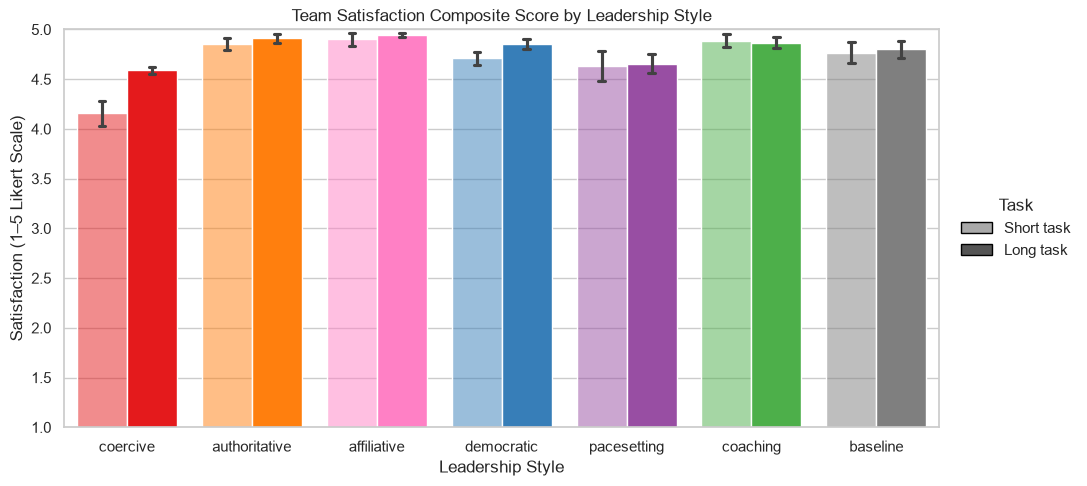

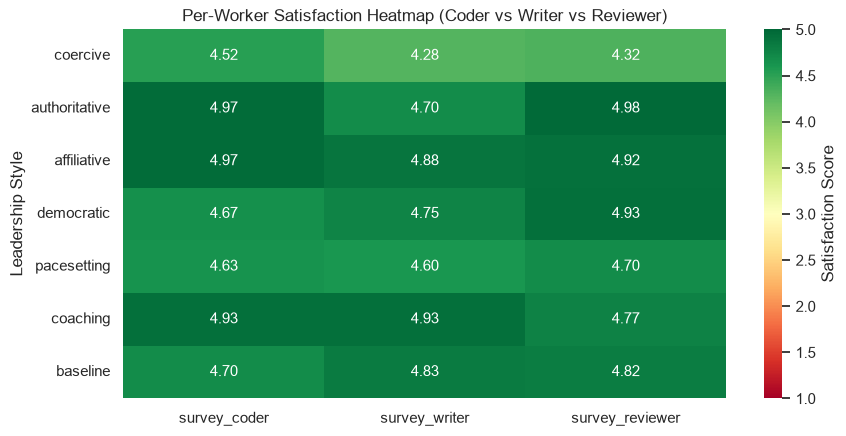

In [23]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=df, x='style', y='survey_team_mean', hue='task', order=STYLE_ORDER, errorbar='se', capsize=0.1, ax=ax, legend=False, hue_order=['short', 'long'])
color_style_task_bars(ax)
add_short_long_legend(ax=ax, loc='center left', bbox_to_anchor=(1.01, 0.5))

ax.set_title('Team Satisfaction Composite Score by Leadership Style')
ax.set_ylabel('Satisfaction (1–5 Likert Scale)')
ax.set_xlabel('Leadership Style')
ax.set_ylim(1, 5)
plt.tight_layout()
save_fig('03_satisfaction_by_style')
plt.show()

# Per worker breakdown
worker_cols = ['survey_coder', 'survey_writer', 'survey_reviewer']
df_worker_sat = df.groupby('style')[worker_cols].mean().reindex(STYLE_ORDER)

plt.figure(figsize=(9, 4.5))
sns.heatmap(df_worker_sat, annot=True, cmap='RdYlGn', fmt='.2f', vmin=1, vmax=5, cbar_kws={'label': 'Satisfaction Score'})
plt.title('Per-Worker Satisfaction Heatmap (Coder vs Writer vs Reviewer)')
plt.ylabel('Leadership Style')
plt.tight_layout()
save_fig('03_satisfaction_worker_heatmap')
plt.show()

### §3.1 — Worker Experience & Survey Breakdown (Q1–Q6)

This grouped horizontal bar chart shows the mean adjusted score for every survey item across the seven leadership styles. 

Use this view to spot:
- **Ceiling effects**
- **Floor effects** 


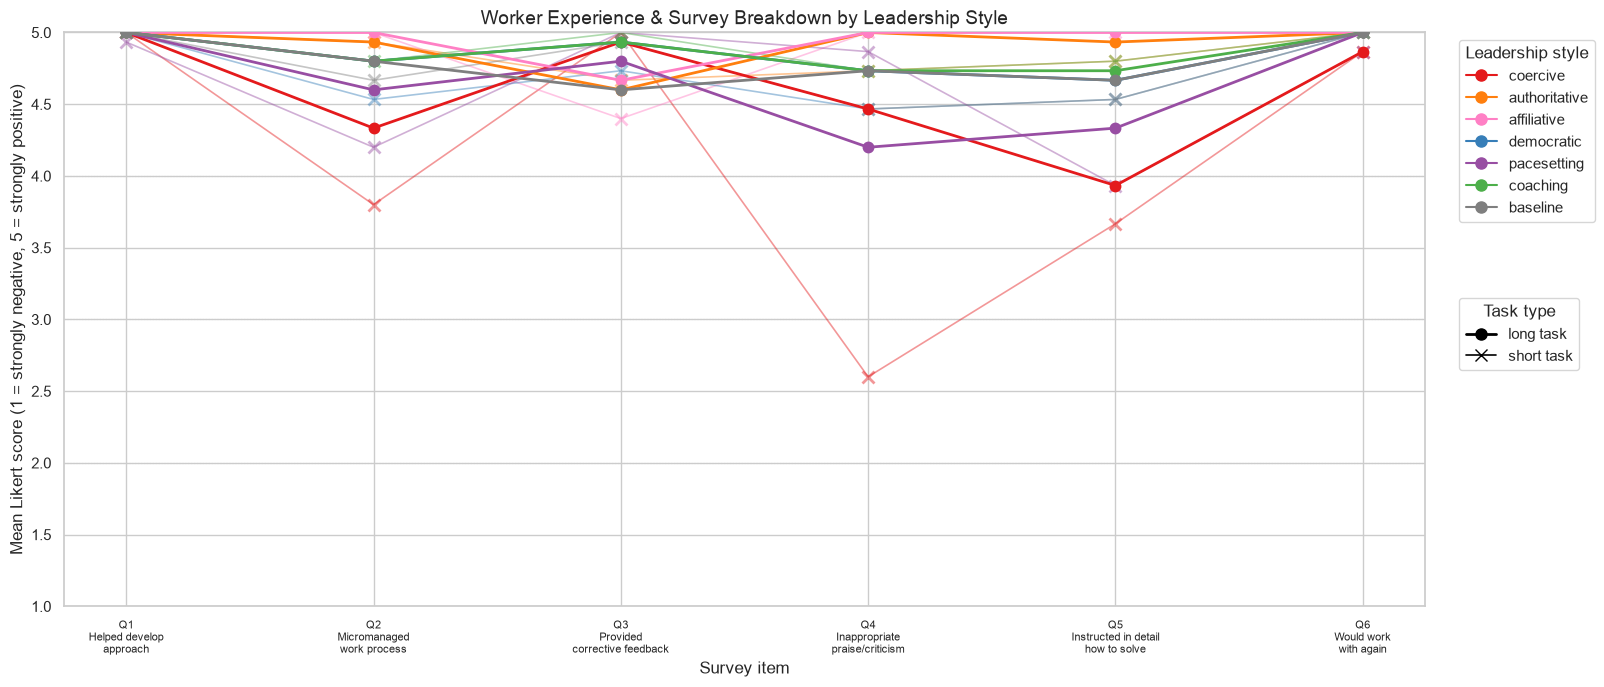

Survey items (reverse-coded items marked with *):
  Q1: The team leader helped the team develop a good approach to the task.
  Q2: The team leader micromanaged the team's work process. *
  Q3: The team leader provided corrective feedback when needed.
  Q4: The team leader gave inappropriate or undeserved praise or criticism. *
  Q5: The team leader instructed the team in detail about how to solve its problems. *
  Q6: I would work with this team leader again on a future task.

Reverse-coded items: Q2, Q4, Q5


In [24]:
SURVEY_ITEM_DESCRIPTIONS = {
    'Q1': 'The team leader helped the team develop a good approach to the task.',
    'Q2': 'The team leader micromanaged the team\'s work process.',
    'Q3': 'The team leader provided corrective feedback when needed.',
    'Q4': 'The team leader gave inappropriate or undeserved praise or criticism.',
    'Q5': 'The team leader instructed the team in detail about how to solve its problems.',
    'Q6': 'I would work with this team leader again on a future task.',
}

SURVEY_ITEM_LABELS = {
    'Q1': 'Q1\nHelped develop\napproach',
    'Q2': 'Q2\nMicromanaged\nwork process',
    'Q3': 'Q3\nProvided\ncorrective feedback',
    'Q4': 'Q4\nInappropriate\npraise/criticism',
    'Q5': 'Q5\nInstructed in detail\nhow to solve',
    'Q6': 'Q6\nWould work\nwith again',
}

# Items that are reverse-coded in the satisfaction survey
REVERSED_ITEMS = {'Q2', 'Q4', 'Q5'}
# Load individual item scores (adjusted) from survey_results.json
item_rows = []
for d in run_dirs:
    surv_path = os.path.join(d, 'survey_results.json')
    if not os.path.exists(surv_path):
        continue
    with open(surv_path, 'r', encoding='utf-8') as f:
        survey = json.load(f)
    folder = os.path.basename(d)
    parts = folder.split('_')
    for worker, wdata in survey.get('workers', {}).items():
        adj = wdata.get('adjusted_scores')
        if not adj:
            continue
        for q, score in adj.items():
            item_rows.append({
                'run': folder,
                'style': parts[0],
                'task': parts[1],
                'worker': worker,
                'item': q.upper(),
                'score': float(score)
            })

df_items = pd.DataFrame(item_rows)
df_items['style'] = pd.Categorical(df_items['style'], categories=STYLE_ORDER, ordered=True)

# Mean score per style, task and item (aggregated across runs and worker roles)
df_item_mean = (df_items.groupby(['style', 'task', 'item'], observed=True)['score']
                         .mean()
                         .reset_index())

item_order = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6']

fig, ax = plt.subplots(figsize=(16, 7))

# One colour per leadership style; long = solid o, short = lighter x
style_handles = []
for style in STYLE_ORDER:
    color = STYLE_COLORS[style]
    for task, marker, alpha, width in [('short', 'x', 0.45, 1.2), ('long', 'o', 1.0, 2.0)]:
        task_data = df_item_mean[
            (df_item_mean['style'] == style) & (df_item_mean['task'] == task)
        ].set_index('item').reindex(item_order)
        ax.plot(
            item_order, task_data['score'],
            color=color,
            marker=marker,
            markersize=8 if marker == 'x' else 7,
            markeredgewidth=2 if marker == 'x' else 1.5,
            linewidth=width,
            alpha=alpha,
            zorder=3 if alpha == 1.0 else 2
        )
    style_handles.append(Line2D([0], [0], color=color, marker='o', markersize=8, label=style))

# Two-part legend: leadership styles, then task markers
style_legend = ax.legend(handles=style_handles, title='Leadership style', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.add_artist(style_legend)

task_handles = [
    Line2D([0], [0], color='black', marker='o', markersize=8, label='long task', linewidth=2),
    Line2D([0], [0], color='black', marker='x', markersize=8, label='short task', linewidth=1.2)
]
ax.legend(handles=task_handles, title='Task type', bbox_to_anchor=(1.02, 0.55), loc='upper left')

# Use the full question descriptions on the x-axis
ax.set_xticks(item_order)
ax.set_xticklabels(
    [SURVEY_ITEM_LABELS[q] for q in item_order],
    rotation=0,
    ha='center'
)
ax.tick_params(axis='x', labelsize=8)

ax.set_ylim(1, 5)
ax.set_ylabel('Mean Likert score (1 = strongly negative, 5 = strongly positive)')
ax.set_xlabel('Survey item')
ax.set_title('Worker Experience & Survey Breakdown by Leadership Style', fontsize=14)

# Highlight the score midpoints to make floor/ceiling easier to read
for y in [2, 3, 4]:
    ax.axhline(y, color='lightgray', linestyle=':', linewidth=0.8, zorder=0)

plt.tight_layout()
save_fig('03_survey_items')
plt.show()

# Print the item text and reverse-coding for reference
print('Survey items (reverse-coded items marked with *):')
for q in item_order:
    marker = ' *' if q in REVERSED_ITEMS else ''
    print(f'  {q}: {SURVEY_ITEM_DESCRIPTIONS[q]}{marker}')
print(f'\nReverse-coded items: {", ".join(sorted(REVERSED_ITEMS))}')

### §3.2 — Within-Run Worker Variance in Satisfaction

Boxplot / strip plot of the composite satisfaction score for each **agent role** (Coder, Writer, Reviewer) within every leadership style.

This helps spot whether certain styles create role-specific dissatisfaction — for example, whether the Coder under **Coercive** or **Pacesetting** scores far below the Writer or Reviewer, or whether warm styles produce uniform, high scores across all three roles.


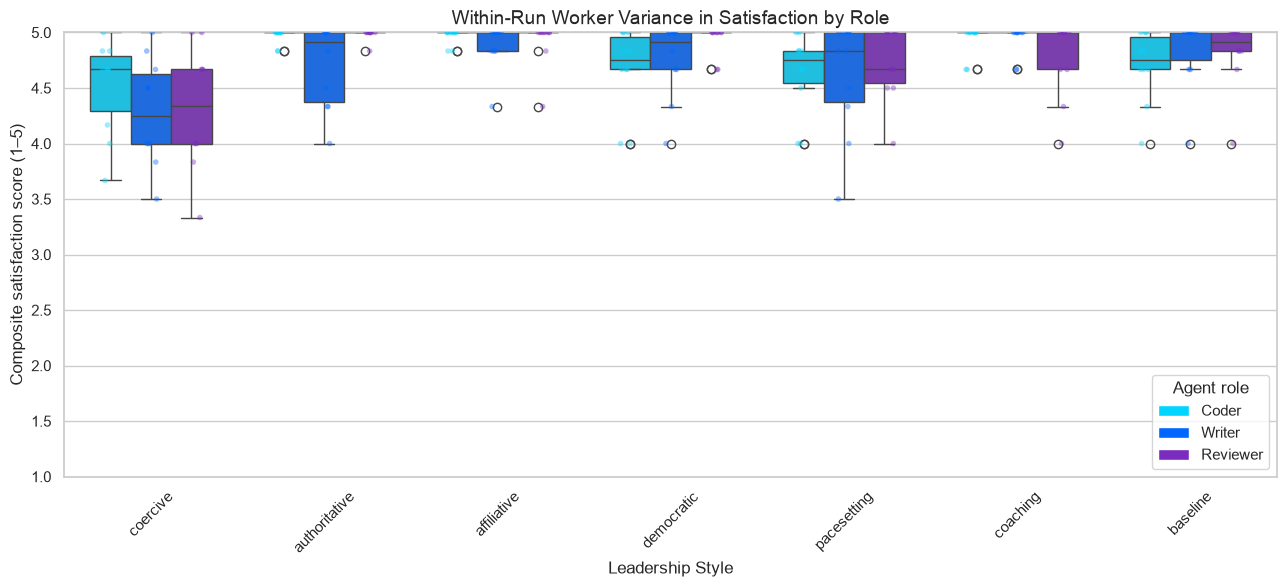

Mean satisfaction by style and role:
role           Coder  Reviewer  Writer
style                                 
coercive        4.52      4.32    4.28
authoritative   4.97      4.98    4.70
affiliative     4.97      4.92    4.88
democratic      4.67      4.93    4.75
pacesetting     4.63      4.70    4.60
coaching        4.93      4.77    4.93
baseline        4.70      4.82    4.83


In [25]:
# Melt the per-role satisfaction columns into long format
df_roles = (df[['style', 'task', 'survey_coder', 'survey_writer', 'survey_reviewer']]
              .melt(id_vars=['style', 'task'],
                    value_vars=['survey_coder', 'survey_writer', 'survey_reviewer'],
                    var_name='role', value_name='satisfaction'))
df_roles['role'] = df_roles['role'].map({
    'survey_coder': 'Coder',
    'survey_writer': 'Writer',
    'survey_reviewer': 'Reviewer'
})
df_roles = df_roles.dropna(subset=['satisfaction'])

# Role color palette (not the style palette)
role_palette = {
    'Coder': '#00D4FF',
    'Writer': '#0066FF',
    'Reviewer': '#7B2CBF'
}

fig, ax = plt.subplots(figsize=(13, 6))

# Boxplots by style, colored by role
sns.boxplot(
    data=df_roles,
    x='style', y='satisfaction', hue='role',
    order=STYLE_ORDER,
    palette=role_palette,
    width=0.7,
    ax=ax
)

# Overlay individual run points
sns.stripplot(
    data=df_roles,
    x='style', y='satisfaction', hue='role',
    order=STYLE_ORDER,
    palette=role_palette,
    dodge=True,
    size=4,
    alpha=0.4,
    linewidth=0,
    ax=ax,
    legend=False
)

ax.set_ylim(1, 5)
ax.set_xlabel('Leadership Style')
ax.set_ylabel('Composite satisfaction score (1–5)')
ax.set_title('Within-Run Worker Variance in Satisfaction by Role', fontsize=14)
ax.tick_params(axis='x', rotation=45)

# Clean legend: show one patch per role
legend_elements = [Patch(facecolor=role_palette[r], edgecolor='white', label=r) for r in role_palette]
ax.legend(handles=legend_elements, title='Agent role', loc='lower right')

plt.tight_layout()
save_fig('03_satisfaction_within_run_variance')
plt.show()

# Quick numeric check: role means by style
print('Mean satisfaction by style and role:')
print(df_roles.groupby(['style', 'role'])['satisfaction'].mean().unstack().round(2).reindex(STYLE_ORDER).to_string())

### §3.3 — Role-Specific Dissatisfaction Slope

Slope chart of the **per-role composite satisfaction** (Coder, Writer, Reviewer) for each leadership style.

- **Faded dots:** individual run scores.
- **Colored lines:** mean satisfaction per style, with 90% confidence intervals.

This reveals whether all workers suffer equally under a demanding style, or whether the Coder — who bears debugging pressure — is systematically more dissatisfied than the Writer or Reviewer.


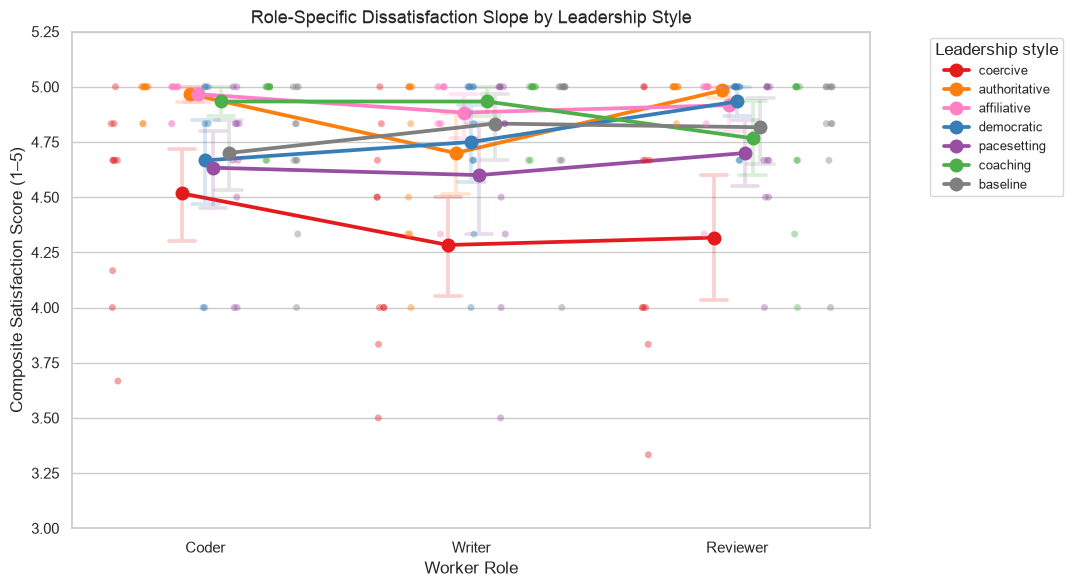

Mean satisfaction by style and role:
role           Coder  Reviewer  Writer
style                                 
coercive        4.52      4.32    4.28
authoritative   4.97      4.98    4.70
affiliative     4.97      4.92    4.88
democratic      4.67      4.93    4.75
pacesetting     4.63      4.70    4.60
coaching        4.93      4.77    4.93
baseline        4.70      4.82    4.83


In [26]:
# Melt per-role satisfaction columns into long format
df_roles = (df[['style', 'survey_coder', 'survey_writer', 'survey_reviewer']]
              .melt(id_vars=['style'],
                    value_vars=['survey_coder', 'survey_writer', 'survey_reviewer'],
                    var_name='role', value_name='satisfaction'))
df_roles['role'] = df_roles['role'].map({
    'survey_coder': 'Coder',
    'survey_writer': 'Writer',
    'survey_reviewer': 'Reviewer'
})
df_roles = df_roles.dropna(subset=['satisfaction'])

fig, ax = plt.subplots(figsize=(11, 6))

# Individual run points in the background
sns.stripplot(
    data=df_roles,
    x='role', y='satisfaction', hue='style',
    order=['Coder', 'Writer', 'Reviewer'],
    hue_order=STYLE_ORDER,
    palette=STYLE_COLORS,
    dodge=True,
    jitter=True,
    size=5,
    alpha=0.4,
    ax=ax,
    legend=False
)

# Mean slope per style with 90% CI
sns.pointplot(
    data=df_roles,
    x='role', y='satisfaction', hue='style',
    order=['Coder', 'Writer', 'Reviewer'],
    hue_order=STYLE_ORDER,
    palette=STYLE_COLORS,
    dodge=True,
    markersize=8,
    linestyles='-',
    errorbar=('ci', 90),
    capsize=0.1,
    err_kws={'alpha': 0.2},
    ax=ax
)

ax.set_ylim(3.0, 5.25)
ax.set_xlabel('Worker Role')
ax.set_ylabel('Composite Satisfaction Score (1–5)')
ax.set_title('Role-Specific Dissatisfaction Slope by Leadership Style', fontsize=13)
ax.legend(title='Leadership style', loc='upper right', bbox_to_anchor=(1.25, 1), fontsize=9)
plt.tight_layout()
save_fig('03_dissatisfaction_slope_by_role')
plt.show()

# Quick numerical check: role means by style
print('Mean satisfaction by style and role:')
print(df_roles.groupby(['style', 'role'])['satisfaction'].mean().unstack().reindex(STYLE_ORDER).round(2).to_string())

## §4 — Extra: Cross-DV, Statistical Testing, and Integrated Summary


### §4.1 — Cross-DV Relationships & Correlations

Examine how Output Quality, Efficiency (Tokens/Duration) and Worker Satisfaction relate to each other.

> **Pooled correlations across both tasks are confounded by task type and must not be interpreted.** The long task systematically consumes more tokens *and* receives higher judge scores than the short task (mean quality 3.94 vs 2.83, p ≈ 1e-9). Any pooled quality–cost correlation therefore mostly reflects "long tasks are bigger and score higher", not "spending more tokens buys quality" — a textbook Simpson's-paradox setup. Every correlation below is therefore reported **three times**: pooled (for reference only), and separately **within the short task** and **within the long task**. Only the within-task values are interpretable.


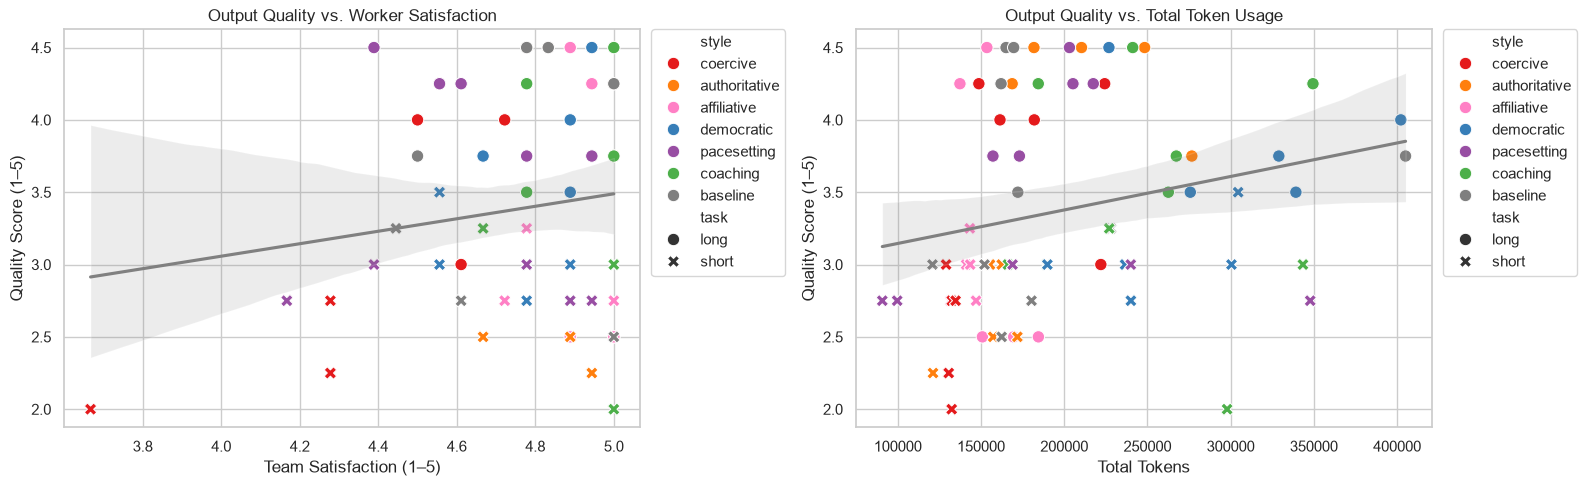

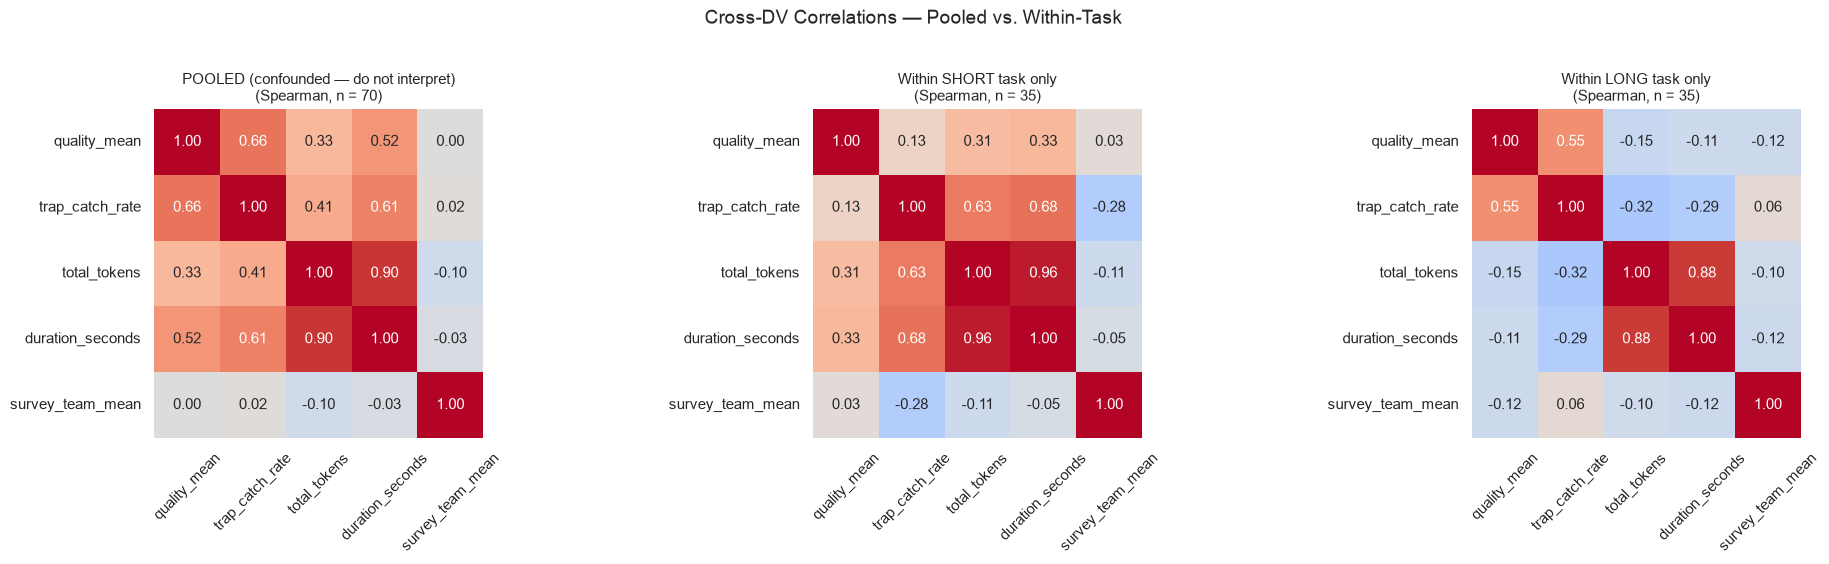

   CROSS-DV CORRELATIONS — POOLED vs. WITHIN TASK
   Only the within-task rows are interpretable; the pooled rows mix two task types.
                    Relationship               Scope  n  Spearman rho  p-value Significant
        Quality  ~  Satisfaction pooled (confounded) 70         0.001   0.9929          No
        Quality  ~  Satisfaction          short task 35         0.034   0.8447          No
        Quality  ~  Satisfaction           long task 35        -0.123   0.4819          No
        Quality  ~  Total tokens pooled (confounded) 70         0.334   0.0047         Yes
        Quality  ~  Total tokens          short task 35         0.309   0.0712          No
        Quality  ~  Total tokens           long task 35        -0.150   0.3883          No
            Quality  ~  Duration pooled (confounded) 70         0.519   0.0000         Yes
            Quality  ~  Duration          short task 35         0.332   0.0515          No
            Quality  ~  Duration           long

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Quality vs Satisfaction
sns.scatterplot(data=df, x='survey_team_mean', y='quality_mean', hue='style', style='task', s=80, palette=STYLE_COLORS, ax=axes[0])
sns.regplot(data=df, x='survey_team_mean', y='quality_mean', scatter=False, ax=axes[0], color='gray')
axes[0].set_title('Output Quality vs. Worker Satisfaction')
axes[0].set_xlabel('Team Satisfaction (1–5)')
axes[0].set_ylabel('Quality Score (1–5)')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, title='')

# Quality vs Tokens
sns.scatterplot(data=df, x='total_tokens', y='quality_mean', hue='style', style='task', s=80, palette=STYLE_COLORS, ax=axes[1])
sns.regplot(data=df, x='total_tokens', y='quality_mean', scatter=False, ax=axes[1], color='gray')
axes[1].set_title('Output Quality vs. Total Token Usage')
axes[1].set_xlabel('Total Tokens')
axes[1].set_ylabel('Quality Score (1–5)')
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, title='')

plt.tight_layout()
save_fig('03_quality_vs_satisfaction_and_tokens')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Correlation matrices: pooled (confounded by task) vs. within each task
# ─────────────────────────────────────────────────────────────────────────────
corr_cols = ['quality_mean', 'trap_catch_rate', 'total_tokens', 'duration_seconds', 'survey_team_mean']

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
panels = [
    ('POOLED (confounded — do not interpret)', df, 'coolwarm'),
    ('Within SHORT task only', df[df['task'] == 'short'], 'coolwarm'),
    ('Within LONG task only', df[df['task'] == 'long'], 'coolwarm'),
]
for ax, (title, data, cmap) in zip(axes, panels):
    cm = data[corr_cols].corr(method='spearman')
    sns.heatmap(cm, annot=True, cmap=cmap, fmt='.2f', vmin=-1, vmax=1, ax=ax,
                cbar=False, square=True)
    ax.set_title(f'{title}\n(Spearman, n = {len(data)})', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
fig.suptitle('Cross-DV Correlations — Pooled vs. Within-Task', fontsize=14, y=1.02)
fig.tight_layout()
save_fig('03_correlations_pooled_vs_within_task')
plt.show()

# ── Explicit significance test of the key pairs, pooled vs. within task ─────
key_pairs = [
    ('quality_mean', 'survey_team_mean', 'Quality  ~  Satisfaction'),
    ('quality_mean', 'total_tokens', 'Quality  ~  Total tokens'),
    ('quality_mean', 'duration_seconds', 'Quality  ~  Duration'),
    ('trap_catch_rate', 'total_tokens', 'Trap catch rate  ~  Total tokens'),
    ('survey_team_mean', 'total_tokens', 'Satisfaction  ~  Total tokens'),
]

rows = []
for a, b, label in key_pairs:
    for scope, data in [('pooled (confounded)', df),
                        ('short task', df[df['task'] == 'short']),
                        ('long task', df[df['task'] == 'long'])]:
        rho, p = stats.spearmanr(data[a], data[b])
        rows.append({
            'Relationship': label,
            'Scope': scope,
            'n': len(data),
            'Spearman rho': round(rho, 3),
            'p-value': round(p, 4),
            'Significant': 'Yes' if p < 0.05 else 'No'
        })

df_corr_bytask = pd.DataFrame(rows)
print('=' * 92)
print('   CROSS-DV CORRELATIONS — POOLED vs. WITHIN TASK')
print('   Only the within-task rows are interpretable; the pooled rows mix two task types.')
print('=' * 92)
print(df_corr_bytask.to_string(index=False))

# ── Headline check: does the pooled quality~tokens correlation survive? ──────
rho_pool, p_pool = stats.spearmanr(df['quality_mean'], df['total_tokens'])
rho_s, p_s = stats.spearmanr(df[df.task == 'short']['quality_mean'], df[df.task == 'short']['total_tokens'])
rho_l, p_l = stats.spearmanr(df[df.task == 'long']['quality_mean'], df[df.task == 'long']['total_tokens'])

print('\n' + '-' * 92)
print('SIMPSON CHECK — Quality vs. Token cost:')
print(f'  pooled     : rho = {rho_pool:+.3f} (p = {p_pool:.4f})  <- driven by task type, NOT by spending')
print(f'  short only : rho = {rho_s:+.3f} (p = {p_s:.4f})')
print(f'  long only  : rho = {rho_l:+.3f} (p = {p_l:.4f})')
if p_s >= 0.05 and p_l >= 0.05:
    print('  -> The pooled association DISAPPEARS within each task. Spending more tokens')
    print('     does not buy higher quality; the pooled correlation was a task artefact.')
else:
    print('  -> At least one within-task association survives; report the within-task values.')
print('-' * 92)

#### §4.1.1 — Quality and Satisfaction are Decoupled (No Trade-off)

This plot addresses the central research question: do leadership styles that deliver high output quality come at the cost of worker satisfaction?

**The answer in this experiment is no — because there is no relationship at all.** Satisfaction varies strongly and significantly across styles, while output quality does not vary detectably. Run-level Spearman correlation between the two is ρ ≈ −0.12 (p ≈ .33), i.e. indistinguishable from zero. The two dependent variables are therefore **decoupled**, not traded off against each other. 

Each point is one leadership style, plotted at the mean satisfaction and mean control-agent quality across all 10 runs (5 short + 5 long). Horizontal and vertical error bars show ±1 SD across those runs. Bubble size is scaled by mean total token consumption, so the *cost* dimension remains visible: it is cost, not quality, that moves with the more discursive styles.

> **How to read it:** the points spread out horizontally (satisfaction differs) but form a flat, noisy band vertically (quality does not). 


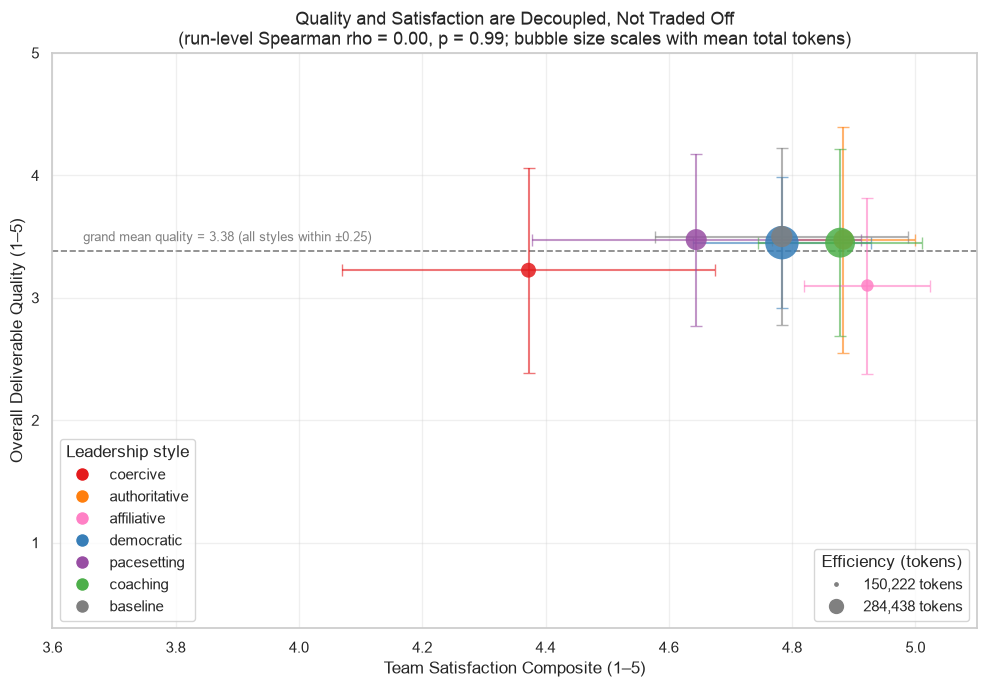

Mean satisfaction, quality and token usage per leadership style:
               satisfaction_mean  satisfaction_std  quality_mean  quality_std  tokens_mean  duration_mean
style                                                                                                    
coercive                   4.372             0.302         3.225        0.837     159756.7        203.511
authoritative              4.883             0.115         3.475        0.924     185403.9        239.652
affiliative                4.922             0.102         3.100        0.719     150222.3        196.669
democratic                 4.784             0.144         3.450        0.537     284438.0        318.839
pacesetting                4.644             0.267         3.475        0.702     190312.0        226.904
coaching                   4.878             0.133         3.450        0.762     252871.9        287.533
baseline                   4.783             0.205         3.500        0.726     19176

In [28]:
# Aggregate to style-level means ± SD
trade = (df.groupby('style', observed=False)
          .agg(
              satisfaction_mean=('survey_team_mean', 'mean'),
              satisfaction_std=('survey_team_mean', 'std'),
              quality_mean=('quality_mean', 'mean'),
              quality_std=('quality_mean', 'std'),
              tokens_mean=('total_tokens', 'mean'),
              duration_mean=('duration_seconds', 'mean')
          )
          .reindex(STYLE_ORDER))

# Bubble size scaled by mean token usage
min_tok, max_tok = trade['tokens_mean'].min(), trade['tokens_mean'].max()
bubble_size = 80 + 500 * ((trade['tokens_mean'] - min_tok) / (max_tok - min_tok))
colors = [STYLE_COLORS[s] for s in trade.index]

fig, ax = plt.subplots(figsize=(10, 7))

# Error bars first, so they sit behind the bubbles.
# NOTE: no Pareto frontier is drawn - see the markdown cell above.
for x, y, sx, sy, c in zip(
    trade['satisfaction_mean'], trade['quality_mean'],
    trade['satisfaction_std'], trade['quality_std'], colors
):
    ax.errorbar(x, y, xerr=sx, yerr=sy,
                fmt='none', ecolor=c, alpha=0.6, capsize=4, zorder=1)

ax.scatter(
    trade['satisfaction_mean'], trade['quality_mean'],
    s=bubble_size, c=colors, alpha=0.85, edgecolors='none', zorder=2
)

# Horizontal reference line at the grand mean quality: makes the flatness explicit
grand_quality = df['quality_mean'].mean()
ax.axhline(grand_quality, color='gray', linestyle='--', linewidth=1.2, zorder=0)
ax.text(3.65, grand_quality + 0.08,
        f'grand mean quality = {grand_quality:.2f} (all styles within ±0.25)',
        fontsize=9, color='gray')

rho_run, p_run = stats.spearmanr(df['survey_team_mean'], df['quality_mean'])

ax.set_xlabel('Team Satisfaction Composite (1–5)', fontsize=12)
ax.set_ylabel('Overall Deliverable Quality (1–5)', fontsize=12)
ax.set_title('Quality and Satisfaction are Decoupled, Not Traded Off\n'
             f'(run-level Spearman rho = {rho_run:.2f}, p = {p_run:.2f}; '
             'bubble size scales with mean total tokens)', fontsize=13)
ax.set_xlim(3.6, 5.1)
ax.set_ylim(0.3, 5.0)
ax.grid(True, alpha=0.3)

# Legend for leadership style colors
style_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=STYLE_COLORS[s], markersize=10, label=s)
    for s in STYLE_ORDER
]
leg1 = ax.legend(handles=style_handles, title='Leadership style',
                 loc='lower left', frameon=True)
ax.add_artist(leg1)

# Legend for bubble size
size_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=np.sqrt(s) / 2, label=lab)
    for s, lab in zip([bubble_size.min(), bubble_size.max()],
                      [f'{int(min_tok):,} tokens', f'{int(max_tok):,} tokens'])
]
ax.legend(handles=size_handles, title='Efficiency (tokens)', loc='lower right')

plt.tight_layout()
save_fig('03_decoupling')
plt.show()

print('Mean satisfaction, quality and token usage per leadership style:')
print(trade.round(3).to_string())
print(f'\nRun-level Spearman(satisfaction, quality) = {rho_run:.3f}, p = {p_run:.3f}')
print(f'Between-style quality spread: {trade["quality_mean"].max() - trade["quality_mean"].min():.2f} points')
print(f'Mean within-style quality SD:  {trade["quality_std"].mean():.2f} points')

-> The spread between styles is smaller than the scatter within a single style, so quality differences between styles are not interpretable. Satisfaction and token cost do differ; quality does not. It is a decoupling, not a trade-off. 


#### §4.1.2 — Descriptive Variants: Quality Subscores against Satisfaction

The same descriptive map, shown for each quality subscore so it is visible that the decoupling is not an artefact of the composite score: no subscore (Accuracy, Completeness, Cohesion) or trap catch rate lines up with satisfaction either. Bubble size is scaled by either total token usage or wall-clock duration, as stated in each subplot title.

> **Descriptive only.** Error bars are ±1 SD across the 10 runs per style. In every panel the error bars overlap heavily, and none of the quality metrics differ significantly across styles.

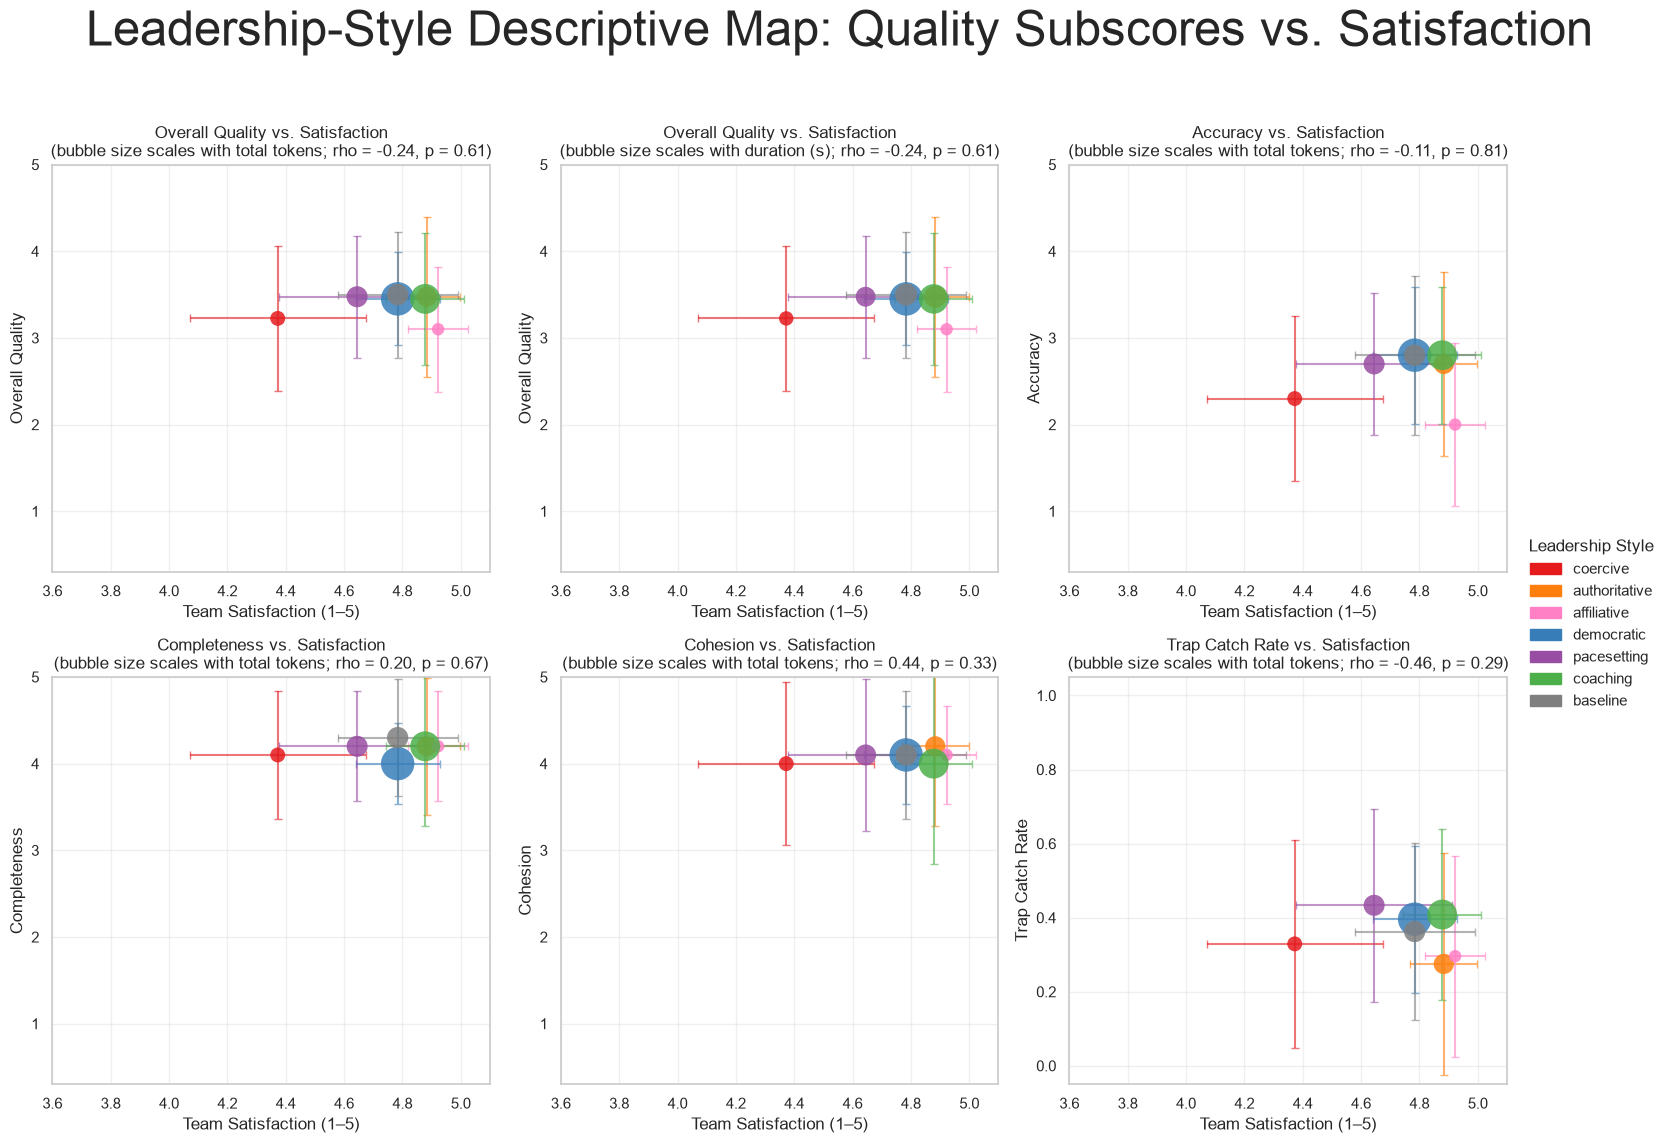

Style-level means for the six descriptive plots:
               satisfaction_mean  quality_mean  accuracy_mean  completeness_mean  cohesion_mean  trap_mean  tokens_mean  duration_mean
style                                                                                                                                 
coercive                   4.372         3.225            2.3                4.1            4.0      0.329     159756.7        203.511
authoritative              4.883         3.475            2.7                4.2            4.2      0.275     185403.9        239.652
affiliative                4.922         3.100            2.0                4.2            4.1      0.296     150222.3        196.669
democratic                 4.784         3.450            2.8                4.0            4.1      0.396     284438.0        318.839
pacesetting                4.644         3.475            2.7                4.2            4.1      0.433     190312.0        226.904
coachi

In [29]:
# Style-level means ± SD for all relevant metrics
agg = (df.groupby('style', observed=False)
       .agg(
           satisfaction_mean=('survey_team_mean', 'mean'),
           satisfaction_std=('survey_team_mean', 'std'),
           quality_mean=('quality_mean', 'mean'),
           quality_std=('quality_mean', 'std'),
           accuracy_mean=('accuracy', 'mean'),
           accuracy_std=('accuracy', 'std'),
           completeness_mean=('completeness', 'mean'),
           completeness_std=('completeness', 'std'),
           cohesion_mean=('cohesion', 'mean'),
           cohesion_std=('cohesion', 'std'),
           trap_mean=('trap_catch_rate', 'mean'),
           trap_std=('trap_catch_rate', 'std'),
           tokens_mean=('total_tokens', 'mean'),
           duration_mean=('duration_seconds', 'mean')
       )
       .reindex(STYLE_ORDER))

color_list = [STYLE_COLORS[s] for s in agg.index]
min_tok, max_tok = agg['tokens_mean'].min(), agg['tokens_mean'].max()
min_dur, max_dur = agg['duration_mean'].min(), agg['duration_mean'].max()

# Plot specifications: (y mean, y std, y label, y-lim, size metric col, size label)
plot_specs = [
    ('quality_mean', 'quality_std', 'Overall Quality', (0.3, 5.0), 'tokens_mean', 'total tokens'),
    ('quality_mean', 'quality_std', 'Overall Quality', (0.3, 5.0), 'duration_mean', 'duration (s)'),
    ('accuracy_mean', 'accuracy_std', 'Accuracy', (0.3, 5.0), 'tokens_mean', 'total tokens'),
    ('completeness_mean', 'completeness_std', 'Completeness', (0.3, 5.0), 'tokens_mean', 'total tokens'),
    ('cohesion_mean', 'cohesion_std', 'Cohesion', (0.3, 5.0), 'tokens_mean', 'total tokens'),
    ('trap_mean', 'trap_std', 'Trap Catch Rate', (-0.05, 1.05), 'tokens_mean', 'total tokens')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, (ym, ys, ylabel, ylim, size_col, size_lab) in zip(axes.flat, plot_specs):
    # bubble size
    min_s, max_s = agg[size_col].min(), agg[size_col].max()
    bubble = 80 + 500 * ((agg[size_col] - min_s) / (max_s - min_s))

    # NOTE: Pareto frontiers deliberately omitted - the between-style spread is
    # far smaller than the within-style SD, so a "frontier" would over-claim.
    for x, y, sx, sy, c in zip(
        agg['satisfaction_mean'], agg[ym],
        agg['satisfaction_std'], agg[ys], color_list
    ):
        ax.errorbar(x, y, xerr=sx, yerr=sy,
                    fmt='none', ecolor=c, alpha=0.6, capsize=3, zorder=1)

    ax.scatter(
        agg['satisfaction_mean'], agg[ym],
        s=bubble, c=color_list, alpha=0.85,
        edgecolors='none', zorder=2
    )

    # Spearman correlation across the 7 style means, for reference
    rho, p_rho = stats.spearmanr(agg['satisfaction_mean'], agg[ym])
    ax.set_title(f'{ylabel} vs. Satisfaction\n'
                 f'(bubble size scales with {size_lab}; rho = {rho:.2f}, p = {p_rho:.2f})')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Team Satisfaction (1–5)')
    ax.set_ylim(ylim)
    ax.set_xlim(3.6, 5.1)
    ax.grid(True, alpha=0.3)

# Shared style color legend on the right
legend_patches = [mpatches.Patch(color=STYLE_COLORS[s], label=s) for s in STYLE_ORDER]
fig.legend(handles=legend_patches, title='Leadership Style', loc='upper right',
           bbox_to_anchor=(0.96, 0.55), frameon=False)

fig.suptitle('Leadership-Style Descriptive Map: Quality Subscores vs. Satisfaction', fontsize=35, y=0.98)
fig.tight_layout(rect=[0.03, 0.03, 0.88, 0.95])
save_fig('03_decoupling_subscores')
plt.show()

print('Style-level means for the six descriptive plots:')
print(agg[['satisfaction_mean', 'quality_mean', 'accuracy_mean', 'completeness_mean',
           'cohesion_mean', 'trap_mean', 'tokens_mean', 'duration_mean']].round(3).to_string())

print('\nSpearman correlation of each quality metric with satisfaction (across the 7 style means):')
for ym, label in [('quality_mean', 'Overall quality'), ('accuracy_mean', 'Accuracy'),
                  ('completeness_mean', 'Completeness'), ('cohesion_mean', 'Cohesion'),
                  ('trap_mean', 'Trap catch rate')]:
    rho, p_rho = stats.spearmanr(agg['satisfaction_mean'], agg[ym])
    print(f'  {label:18s} rho = {rho:+.2f}   p = {p_rho:.3f}')
print('\n-> No quality metric tracks satisfaction. Satisfaction and output quality are'
      '\n   decoupled in this experiment, they do not trade off against each other.')

### §4.2 — Non-Parametric Statistical Testing

Perform Kruskal-Wallis non-parametric tests across the 7 leadership styles for Output Quality, Efficiency, and Worker Satisfaction, followed by pairwise Mann-Whitney U tests for significant metrics. Because we test each metric against a common baseline, p-values are reported with and without a Bonferroni correction (α = 0.05 / 6 ≈ 0.0083). Effect sizes are reported as r = |z| / √N. We use non-parametric tests because the sample size is small (5 runs per condition) and the scores are bounded ordinal/ Likert-like values.

In [30]:
stats_results = []
pairwise_rows = []

metrics_to_test = {
    'Output Quality': 'quality_mean',
    'Accuracy (judge)': 'accuracy',
    'Trap Catch Rate': 'trap_catch_rate',
    'Total Tokens': 'total_tokens',
    'Duration (s)': 'duration_seconds',
    'Team Satisfaction': 'survey_team_mean'
}

# ── Kruskal-Wallis tests by task type ───────────────────────────
for name, col in metrics_to_test.items():
    for task_type in sorted(df['task'].dropna().unique()):
        df_task = df[df['task'] == task_type]
        groups = [
            df_task[df_task['style'] == s][col].dropna().values
            for s in STYLE_ORDER
        ]
        if all(len(g) > 0 for g in groups):
            H, p = stats.kruskal(*groups)
            stats_results.append({
                'Metric': name,
                'Task': task_type,
                'H-Statistic': round(H, 3),
                'p-value': round(p, 4),
                'Significant (p < .05)': 'Yes' if p < 0.05 else 'No'
            })

df_stats = pd.DataFrame(stats_results)
print('=' * 70)
print('   KRUSKAL-WALLIS TEST RESULTS BY TASK TYPE')
print('=' * 70)
print(df_stats.to_string(index=False))

# ── Pairwise post-hoc: baseline vs. each style ──────────────────
comparisons = len(STYLE_ORDER) - 1
alpha_bonf = 0.05 / comparisons

for (metric, col) in metrics_to_test.items():
    for task_type in sorted(df['task'].dropna().unique()):
        df_task = df[df['task'] == task_type]
        kw = df_stats[(df_stats['Metric'] == metric) & (df_stats['Task'] == task_type)]
        if kw.empty or kw['p-value'].values[0] >= 0.05:
            continue

        baseline_vals = df_task[df_task['style'] == 'baseline'][col].dropna().values
        if len(baseline_vals) == 0:
            continue

        for style in STYLE_ORDER:
            if style == 'baseline':
                continue
            style_vals = df_task[df_task['style'] == style][col].dropna().values
            if len(style_vals) == 0:
                continue

            U, p = stats.mannwhitneyu(baseline_vals, style_vals, alternative='two-sided')
            n1, n2 = len(baseline_vals), len(style_vals)
            n = n1 + n2
            mean_U = n1 * n2 / 2
            sd_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
            z = (U - mean_U) / sd_U
            r = abs(z) / np.sqrt(n)

            pairwise_rows.append({
                'Metric': metric,
                'Task': task_type,
                'Style': style,
                'baseline_mean': round(np.mean(baseline_vals), 2),
                'style_mean': round(np.mean(style_vals), 2),
                'U-Statistic': round(U, 1),
                'p-value': round(p, 4),
                'p < 0.05': 'Yes' if p < 0.05 else 'No',
                'p < Bonferroni': 'Yes' if p < alpha_bonf else 'No',
                'Effect r': round(r, 3)
            })

df_pairwise = pd.DataFrame(pairwise_rows)
print('\n' + '=' * 70)
print('   PAIRWISE MANN-WHITNEY U: baseline vs. each style')
print(f'   Bonferroni-corrected threshold: {alpha_bonf:.4f}')
print('=' * 70)
if not df_pairwise.empty:
    sig = df_pairwise[df_pairwise['p < 0.05'] == 'Yes']
    print(sig.to_string(index=False) if not sig.empty else 'No pairwise differences at p < .05.')
else:
    print('No pairwise comparisons to report (no significant K-W results).')

   KRUSKAL-WALLIS TEST RESULTS BY TASK TYPE
           Metric  Task  H-Statistic  p-value Significant (p < .05)
   Output Quality  long        5.864   0.4385                    No
   Output Quality short        7.436   0.2824                    No
 Accuracy (judge)  long        7.376   0.2874                    No
 Accuracy (judge) short        9.425   0.1511                    No
  Trap Catch Rate  long        0.717   0.9941                    No
  Trap Catch Rate short       10.134   0.1191                    No
     Total Tokens  long       17.375   0.0080                   Yes
     Total Tokens short       17.802   0.0067                   Yes
     Duration (s)  long       17.570   0.0074                   Yes
     Duration (s) short       19.097   0.0040                   Yes
Team Satisfaction  long       15.814   0.0148                   Yes
Team Satisfaction short       16.083   0.0133                   Yes

   PAIRWISE MANN-WHITNEY U: baseline vs. each style
   Bonferroni-corre

In [31]:
# Verification: quality null-result numbers used in the presentation
# Reproduces the Kruskal-Wallis p-values, epsilon-squared, and overall style quality means.

metrics = {
    'Output quality': 'quality_mean',
    'Accuracy': 'accuracy',
    'Trap catch rate': 'trap_catch_rate',
}

kw_rows = []
for metric_name, col in metrics.items():
    for task in ['short', 'long']:
        df_task = df[df['task'] == task]
        groups = [df_task[df_task['style'] == s][col].dropna().values for s in STYLE_ORDER]
        H, p = stats.kruskal(*groups)
        n = sum(len(g) for g in groups)
        k = len(groups)
        eps2 = (H - k + 1) / (n - k) if n > k else np.nan
        kw_rows.append({
            'Metric': metric_name,
            'Task': task,
            'p': p,
            'epsilon^2': eps2,
        })

kw_df = pd.DataFrame(kw_rows)
print('Kruskal-Wallis p-values and epsilon-squared:')
for _, r in kw_df.iterrows():
    p_str = f"{r['p']:.2f}" if r['p'] >= 0.01 else f"{r['p']:.3f}"
    e_str = f"{r['epsilon^2']:.2f}" if r['epsilon^2'] >= 0.01 else '<0.01'
    print(f"  {r['Metric']:18s} {r['Task']:5s}  p = {p_str},  ε² = {e_str}")

# Overall quality mean by style (pooled across short and long)
style_summary = (df.groupby('style')['quality_mean']
                   .agg(['mean', 'std', 'count'])
                   .reindex(STYLE_ORDER))
print('\nOverall quality_mean by style:')
print(style_summary.round(3).to_string())

style_means = style_summary['mean']
print(f"\nStyle mean range: {style_means.min():.2f} – {style_means.max():.2f}")
print(f"Between-style spread: {style_means.max() - style_means.min():.2f}")
print(f"Mean within-condition SD: {style_summary['std'].mean():.2f}")

Kruskal-Wallis p-values and epsilon-squared:
  Output quality     short  p = 0.28,  ε² = 0.05
  Output quality     long   p = 0.44,  ε² = <0.01
  Accuracy           short  p = 0.15,  ε² = 0.12
  Accuracy           long   p = 0.29,  ε² = 0.05
  Trap catch rate    short  p = 0.12,  ε² = 0.15
  Trap catch rate    long   p = 0.99,  ε² = <0.01

Overall quality_mean by style:
                mean    std  count
style                             
coercive       3.225  0.837     10
authoritative  3.475  0.924     10
affiliative    3.100  0.719     10
democratic     3.450  0.537     10
pacesetting    3.475  0.702     10
coaching       3.450  0.762     10
baseline       3.500  0.726     10

Style mean range: 3.10 – 3.50
Between-style spread: 0.40
Mean within-condition SD: 0.74


#### §4.2.1 — Statistical Power and the Minimum Detectable Effect

A non-significant test can mean two different things: *the effect is absent*, or *the design was too small to see it*. With **7 conditions × 5 repetitions**, this experiment is small, so the distinction has to be made explicitly rather than assumed.

**Statistical power** is the probability that a test detects an effect *given that the effect is really there*. Power rises with sample size and with effect size, and falls with measurement noise. The convention is 80% power; below that, a null result is weak evidence of absence.

The **minimum detectable effect (MDE)** turns this around into something concrete: given the observed noise and n = 5 per condition, *how large would the true difference between the best and worst leadership style have to be* before this design would reliably flag it? Anything smaller than the MDE is invisible to us by construction.

The simulation below estimates the MDE for each dependent variable directly from the observed within-condition noise:

1. Take the mean within-condition standard deviation actually observed in the data (5 runs, identical prompt).
2. Assume the 7 style means are evenly spaced across a hypothetical true range `R`.
3. Draw 7 × 5 synthetic runs, run the same Kruskal-Wallis test, and record whether p < .05.
4. Repeat, increasing `R` until the test succeeds in 80% of simulations. That value of `R` is the MDE.

   MINIMUM DETECTABLE EFFECT — 7 styles x 5 reps, Kruskal-Wallis, alpha = 0.05, target power = 80%
                    Metric  Task  Within-cond SD  Observed range  MDE (80% power)  MDE in SD units  Observed / MDE  Power at observed range Detectable?
    Output quality (judge) short           0.306           0.500            0.703              2.3            0.71                     0.49          no
    Output quality (judge)  long           0.499           1.050            1.148              2.3            0.91                     0.75          no
          Accuracy (judge) short           0.270           0.600            0.621              2.3            0.97                     0.78          no
          Accuracy (judge)  long           0.694           1.600            1.597              2.3            1.00                     0.82         yes
   Trap catch rate (judge) short           0.163           0.267            0.376              2.3            0.71                     0.43  

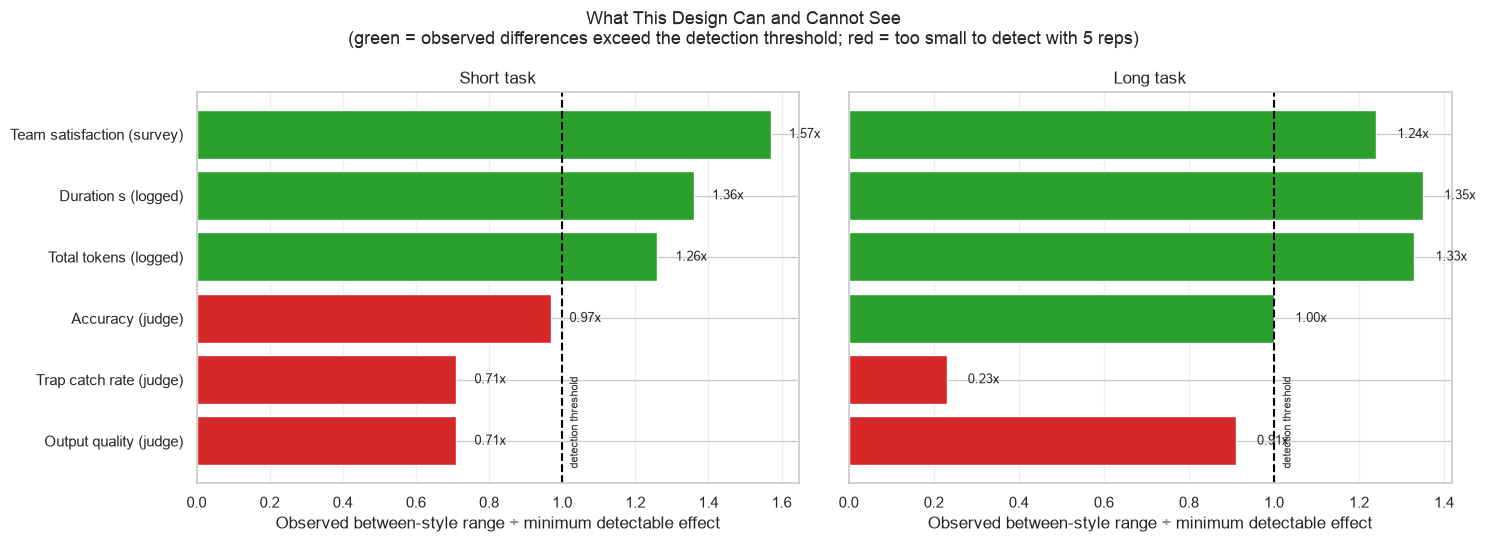

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Minimum detectable effect (MDE) by simulation, using the noise actually
# observed in the data. Answers: "how big would a true style difference have to
# be for 7 conditions x 5 reps to detect it 80% of the time?"
# ─────────────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(16)

N_PER_CELL = 5
N_STYLES = len(STYLE_ORDER)
N_SIMS = 1500
TARGET_POWER = 0.80
ALPHA = 0.05


def simulated_power(true_range, sd, n_per_cell=N_PER_CELL, n_sims=N_SIMS):
    """Power of a 7-group Kruskal-Wallis test when the true style means are
    evenly spaced over `true_range` and within-condition noise is `sd`."""
    if sd == 0:
        return 1.0
    true_means = np.linspace(0, true_range, N_STYLES)
    hits = 0
    for _ in range(n_sims):
        groups = [rng.normal(m, sd, n_per_cell) for m in true_means]
        try:
            _, p = stats.kruskal(*groups)
        except ValueError:      # all values identical
            continue
        if p < ALPHA:
            hits += 1
    return hits / n_sims


def find_mde(sd, max_multiple=8.0, step=0.1):
    """Smallest true best-worst range (in raw units) reaching TARGET_POWER."""
    multiple = step
    while multiple <= max_multiple:
        if simulated_power(multiple * sd, sd) >= TARGET_POWER:
            return multiple * sd, multiple
        multiple += step
    return np.nan, np.nan


power_metrics = {
    'Output quality (judge)': 'quality_mean',
    'Accuracy (judge)': 'accuracy',
    'Trap catch rate (judge)': 'trap_catch_rate',
    'Team satisfaction (survey)': 'survey_team_mean',
    'Total tokens (logged)': 'total_tokens',
    'Duration s (logged)': 'duration_seconds',
}

power_rows = []
for label, col in power_metrics.items():
    for task in ['short', 'long']:
        sub = df[df['task'] == task]
        # Noise = mean within-condition SD across the 7 styles (5 reps each)
        sd = sub.groupby('style')[col].std().mean()
        style_means = sub.groupby('style')[col].mean()
        observed_range = style_means.max() - style_means.min()
        mde, mde_in_sd = find_mde(sd)
        obs_power = simulated_power(observed_range, sd)
        power_rows.append({
            'Metric': label,
            'Task': task,
            'Within-cond SD': round(sd, 3),
            'Observed range': round(observed_range, 3),
            'MDE (80% power)': round(mde, 3) if not np.isnan(mde) else 'n/a',
            'MDE in SD units': round(mde_in_sd, 2) if not np.isnan(mde_in_sd) else 'n/a',
            'Observed / MDE': round(observed_range / mde, 2) if mde and not np.isnan(mde) else 'n/a',
            'Power at observed range': round(obs_power, 2),
            'Detectable?': 'yes' if (not np.isnan(mde) and observed_range >= mde) else 'no',
        })

df_power = pd.DataFrame(power_rows)

print('=' * 100)
print(f'   MINIMUM DETECTABLE EFFECT — {N_STYLES} styles x {N_PER_CELL} reps, '
      f'Kruskal-Wallis, alpha = {ALPHA}, target power = {TARGET_POWER:.0%}')
print('=' * 100)
print(df_power.to_string(index=False))

# ── Visual: observed spread vs. what the design can see ─────────────────────
# Use ONE shared row order for both panels (sharey=True means the panels must
# agree on the category order, otherwise labels and bars get mismatched).
_short = df_power[df_power['Task'] == 'short'].copy()
_short['ratio'] = pd.to_numeric(_short['Observed / MDE'], errors='coerce')
metric_order = _short.sort_values('ratio')['Metric'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, task in zip(axes, ['short', 'long']):
    sub = df_power[df_power['Task'] == task].copy()
    sub['ratio'] = pd.to_numeric(sub['Observed / MDE'], errors='coerce')
    sub = sub.set_index('Metric').reindex(metric_order).reset_index()
    colors = ['#2ca02c' if r >= 1 else '#d62728' for r in sub['ratio']]
    ax.barh(sub['Metric'], sub['ratio'], color=colors, edgecolor='white')
    ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5)
    ax.text(1.02, -0.45, 'detection threshold', rotation=90, fontsize=8, va='bottom')
    ax.set_xlabel('Observed between-style range ÷ minimum detectable effect')
    ax.set_title(f'{task.capitalize()} task')
    for y, r in enumerate(sub['ratio']):
        ax.text(r + 0.05, y, f'{r:.2f}x', va='center', fontsize=9)
    ax.grid(True, axis='x', alpha=0.3)

fig.suptitle('What This Design Can and Cannot See\n'
             '(green = observed differences exceed the detection threshold; '
             'red = too small to detect with 5 reps)', fontsize=13)
fig.tight_layout()
save_fig('03_power_mde')
plt.show()

Interpretation:
- With 5 repetitions the design only reliably detects between-style differences of roughly 2-3 within-condition standard deviations.
- Metrics in RED are not "unaffected by leadership style"; they are UNDER-POWERED. The correct claim is "no detectable difference at n=5".
- Metrics in GREEN are adequately powered, so those effects are robust.
- To halve the MDE, repetitions would have to roughly quadruple (n≈20 per cell, i.e. 280 runs total), because the standard error scales with 1/sqrt(n).

I will discuss this in the thesis in limitations / future work.